# Oracle Sketching for IID data and Sparse Matrices #

In [1]:
import qiskit.circuit
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, PauliGate, UnitaryGate, StatePreparation, IntegerComparator, MCPhaseGate, GlobalPhaseGate, DiagonalGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import qiskit.quantum_info as qi
from qiskit.quantum_info import Operator, Statevector, DensityMatrix, Pauli, random_density_matrix
from qiskit import transpile

from IPython.display import display, Image, Markdown, Latex
import matplotlib.pyplot as plt
import numpy as np
import math
import scipy as sp
import copy
import json
from numpy.typing import ArrayLike, NDArray

import pyqsp
from extra_routines.sign_function_qsvt import *
from extra_routines.oracle_functions import *
from qiskit_aer import AerSimulator

In this notebook we implement toy examples for the Oracle Sketching procedure from appendix D of the paper "Exponential quantum advantage in processing massive classical data" by Haimeng Zhao, Alexander Zlokapa, Hartmut Neven, Ryan Babbush, John Preskill, Jarrod R. McClean, Hsin-Yuan Huang (https://arxiv.org/abs/2604.07639). We build qiskit functions that produce objects of the `QuantumCircuit` class for the following:

1. Oracle Sketching for IID data of a Boolean function (Appendix D.2)
1. Oracle Sketching for IID data of a multi-bit output function (Appendix D.4.a)
1. Element Oracle Sketching for sparse matrices (Appendix D.5.b)
1. Row and Column Index Oracle Sketching for dense matrices (Appendix D.5.b)

We show diagrams of the circuits, and write functions to test that they produce approximately the correct output. Note that these oracles are based on the idea of a data generation process, where we collect samples of a dataset, and the collected data samples dictate which gates we apply in our circuit. This has the advantage of need storing a massive dataset in classical or QROM/ QRAM memory. It also means that the oracles are all inherently approximations of some desired oracle, and relies on concentration around the mean for sufficiently large sample sizes. This means that our Oracles have a nonzero probability to yield the wrong Statevector, which we also investigate. There are other procedures such as the Quantum Singular Value Transformation.

## Oracle sketching for IID data ##

We start with the toy case from the paper, Algorithm 1 from section D.2. The setup is that we have 	$M$ data samples $(x_i,f(x_i))$ for $f \colon [N] \to \left\{0,1 \right\}$. The paper also includes a probability distribution $p(x)$ on $[N]$, but for now we take the uniform distribution $p(x) = 1/N$.

In this case, the sketching Oracle is a circuit that implements the gate 
$V = \prod_{i=1}^M V_i$, where 
$$
 V_i = \exp \left( i \frac{y_i t}{M} | x_i \rangle \langle x_i | \right),
$$
where $y_i = f(x_i)$.
To approximates the phase oracle 
$ O = \sum_{x=1}^N (-1)^{f(x)}| x_i \rangle \langle x_i |$, we would set $t = M \pi$.

First let's create a Boolean function on $[N]$ and then take $M$ independent samples from it.

In [ ]:
N = 16
M=8

np.random.seed(0)
domain = np.arange(N)
outputs = [np.random.randint(0,2) for i in range(N)]
true_binary_function = np.array(list(zip(domain,outputs))) #represent f as list of tuples [x,f(x)]

In [70]:
def exampleboolfunction(x):
    return true_binary_function[x][1]

In [71]:
for k in range(N):
    print(f'f({k}) = {exampleboolfunction(k)}')

f(0) = 0
f(1) = 1
f(2) = 1
f(3) = 0
f(4) = 1
f(5) = 1
f(6) = 1
f(7) = 1
f(8) = 1
f(9) = 1
f(10) = 1
f(11) = 0
f(12) = 0
f(13) = 1
f(14) = 0
f(15) = 0


In [100]:
M = 16
binary_samples = np.zeros((M,2))
np.random.seed(0)
for k in range(M):
    index = np.random.randint(0,N)
    binary_samples[k] = true_binary_function[index,:]
print(f'samples of f: \n {binary_samples}')

samples of f: 
 [[12.  0.]
 [15.  0.]
 [ 5.  1.]
 [ 0.  0.]
 [ 3.  0.]
 [11.  0.]
 [ 3.  0.]
 [ 7.  1.]
 [ 9.  1.]
 [ 3.  0.]
 [ 5.  1.]
 [ 2.  1.]
 [ 4.  1.]
 [ 7.  1.]
 [ 6.  1.]
 [ 8.  1.]]


Now we create a quantum circuit to implement the phase oracle based on the sample data. We also need to know the value $[N]$, which is the `domain_size` variable in our function. The `sample_data` should come in the form of an $M \times 2$ array. Note that we implement each $V_i$ as a multicontrolled phase, with control $|x_i \rangle \langle x_i|$ and phase $t/M$ when $y_i = 1$. When $y_i=0$, we simply do not apply a gate. One can check easily from the definition of the exponential map that $V_i$ acts as identity on all basis states other than $|x_i \rangle$.

In [62]:
def boolean_oracle_sketching_circuit(domain_size, sample_data, tval):
    ''' Implements Algorithm 1: Quantum Oracle sketching approximating phase oracle
    for a boolean function as described above. Outputs appropriate QuantumCircuit object'''
    num_qubits = int(math.ceil(math.log2(domain_size)))
    quantum_register = QuantumRegister(num_qubits,name='q')
    oracle_circuit = QuantumCircuit(quantum_register)   
    sample_size = len(sample_data)
    for i in range(sample_size):
        if int(sample_data[i][1]) == 1:
            target_state = int(sample_data[i][0])
            target_string = f'{target_state:0{num_qubits}b}'[::-1] #Reversed for Little Endian
            oracle_circuit.barrier()
            for k in range(num_qubits):
                if target_string[k] == '0':
                    oracle_circuit.x(quantum_register[k]) #send x_i to all 1s
            oracle_circuit.barrier()
            oracle_circuit.mcp(tval/sample_size, control_qubits = quantum_register[1:], target_qubit = quantum_register[0]) #control state = all 1s
            oracle_circuit.barrier()
            for k in range(num_qubits):
                if target_string[k] == '0':
                    oracle_circuit.x(quantum_register[k])
    return oracle_circuit

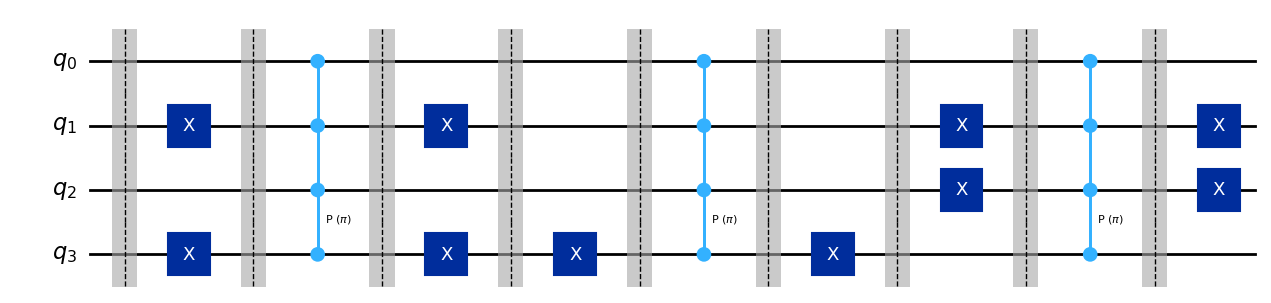

In [63]:
oracle_example = boolean_oracle_sketching_circuit(N,binary_samples[:10], 10*np.pi) #5,7,9 applied
oracle_example.draw(output='mpl')

We use `Statevector` to verify our circuit on our chosen sample list. We take $t = M \pi$, so that the phase of a basis state $| x \rangle$ will be $(-1)^{c(x)f(x)}$, where $c(x)$ is the number of times $x$ appears in the sample list. Therefore, $x$ that appear an even number of times will be unchanged by the oracle circuit.

In [99]:
binary_samples

array([[12.,  0.],
       [15.,  0.],
       [ 5.,  1.],
       [ 0.,  0.],
       [ 3.,  0.],
       [11.,  0.],
       [ 3.,  0.],
       [ 7.,  1.]])

In [ ]:
np.sum(np.where(binary_samples ))

In [103]:
tval = N*np.pi
oracle_example = boolean_oracle_sketching_circuit(N,binary_samples, tval)
bitcount = int(math.ceil(np.log2(N)))
counter = 0
for k in range(N):
    phase_shift = tval/len(binary_samples) # shift applied by V_i
    times_in_sample = len(np.where(binary_samples[:,:1] == k)[0]) # number of times state k appears in sample
    desired_phase = phase_shift*times_in_sample*exampleboolfunction(k) # (times applied) y_i t/ M

    starting_statevector = Statevector.from_int(k,2**bitcount) # |k>
    target_state = np.exp(desired_phase*1j)*starting_statevector # e^{i f(x) c(i)}

    psi = starting_statevector.evolve(oracle_example)

    if np.sum(np.abs(psi.data - target_state.data)**2) > 1e-10:
        print(f'k = {k} failed')
        display('target = ',target_state.draw("latex"))
        display('our statevector =',psi.draw("latex"))
        counter += 1
if counter == 0:
    print('All tests passed!')


All tests passed!


## Multi-bit version ##

In this case, we have a function $f \colon [N] \to \{ 0,1 \}^b$. The idea is that we store states as $|x \rangle | b  \rangle $, because we can think of $f$ as a *subset* of $[N] \times [b]$ instead of a function $[N] \to \{ 0,1 \} \times [b]$. The algorithm is the same, except that for each sample $(x_i,y_i)$ we apply
$$ V_{i,j} = \exp \left( \frac{it (y_i)_j}{M} | x_i, j \rangle \langle x_i, j | \right), $$
for each $j \in [b]$.
This is the same idea as before, except now we have $N + \log_2(b)$ qubits instead of $N$. Note that superposition and binary expansion is used to efficiently store the output of the function. $|x_i, j \rangle \langle x_i, j |$ gets flipped iff the $j$ th bit of $f(x_i)$ is 1.

By applying all of our $V_{i,j}$ gates for a random sample of $(x_i,y_i)$, we are approximating the unitary

$$
U = \sum_{x,j} e^{i p(x) f_j(x) t} |x, j \rangle \langle x, j |,
$$
where $p(x)$ is the probability of choosing $x$ when sampling. Note that if we want to implement a phase flip oracle for a uniform distribution, we if we set $t = N \pi$ we can then approximate the phase oracle
$$
O \colon |x, j \rangle \mapsto (-1)^{f_j(x)} |x, j \rangle.
$$

Important convention to note: the conversion from values of $|j \rangle$ to $f(x)$ is such that the value $|0 \rangle$ on the '$b$' register corresponds to the *least* significant digit of the binary expansion of $j$. So the state $|x_i, 0 \rangle $ being flipped would tell us that the binary representation of $f(x_i)$ is of the form $y_b y_{b-1} \dots 1$ in Big endian notation. Conversely, if the least significant bit is $0$, then the state $|x_i, 0 \rangle$ is unchanged by the sketching oracle.


In [174]:
domain_size = 16
codomain_size = 8
np.random.seed(0)

inputs = np.arange(domain_size)
outputs = [np.random.randint(0,codomain_size) for i in range(domain_size)]
true_function = np.array(list(zip(inputs,outputs))) #represent f as an N x 2 array
print('true function is')
print(true_function)

true function is
[[ 0  4]
 [ 1  7]
 [ 2  5]
 [ 3  0]
 [ 4  3]
 [ 5  3]
 [ 6  3]
 [ 7  7]
 [ 8  1]
 [ 9  3]
 [10  5]
 [11  2]
 [12  4]
 [13  7]
 [14  6]
 [15  0]]


In [183]:
def examplemultibit(x):
    if x >= domain_size or x < 0:
        raise ValueError(f'x must be integer in [0,{domain_size})')
    return true_function[x][1]

In [186]:
for x in range(domain_size):
    print(f'f({x}) = {examplemultibit(x)}')

f(0) = 4
f(1) = 7
f(2) = 5
f(3) = 0
f(4) = 3
f(5) = 3
f(6) = 3
f(7) = 7
f(8) = 1
f(9) = 3
f(10) = 5
f(11) = 2
f(12) = 4
f(13) = 7
f(14) = 6
f(15) = 0


In [208]:
sample_size = 32
multibitsamples = np.zeros((sample_size,2))
np.random.seed(1)
for k in range(sample_size):
    index = np.random.randint(0,domain_size)
    multibitsamples[k] = true_function[index,:]
# print('example samples are \n',multibitsamples)

In [197]:
def multi_oracle_sketching_circuit(domain_size, codomain_size, sample_data, tval):
    ''' Implements Algorithm 1: Quantum Oracle sketching as described above. Outputs appropriate QuantumCircuit object. 
    Underlying function from [domain_size] -> [codomain_size].'''

    bit_length = int(math.ceil(math.log2(codomain_size)))

    num_qubits_x = int(math.ceil(math.log2(domain_size)))
    num_qubits_b = int(math.ceil(math.log2(bit_length)))

    quantum_register_x = QuantumRegister(num_qubits_x,name='x')
    quantum_register_b = QuantumRegister(num_qubits_b,name='b')

    oracle_circuit = QuantumCircuit(quantum_register_x,quantum_register_b)   
    
    sample_size = len(sample_data)

    for i in range(sample_size):
        if int(sample_data[i][1]) != 0:
            
            target_state_x = int(sample_data[i][0])
            target_string_x = f'{target_state_x:0{num_qubits_x}b}'[::-1]
    
            target_state_b = int(sample_data[i][1])
            target_string_b = f'{target_state_b:0{bit_length}b}'[::-1] # f(x) as b-length string
            # print(f'f({target_state_x}) = {target_state_b}')
            # print('binary=',target_string_x,target_string_b)

            for m in range(num_qubits_x): # send x_i to all 1s
                if int(target_string_x[m]) == 0:
                        oracle_circuit.x(quantum_register_x[m])

            oracle_circuit.barrier()

            for j in range(bit_length): # iterate over b register
                y_i_j = int(target_string_b[j]) # this is f(x)_j, j in [b]
                j_string = f'{j:0{num_qubits_b}b}'[::-1]

                for l in range(num_qubits_b): # |j> -> all 1s
                    if int(j_string[l]) == 0:
                        oracle_circuit.x(quantum_register_b[l])

                phase = tval*y_i_j/sample_size # t (y_i)_j/ M
                oracle_circuit.mcp(phase, control_qubits = quantum_register_x[:] + quantum_register_b[:-1], target_qubit = quantum_register_b[-1]) #target vs controls doesn't matter for mcp

                for l in range(num_qubits_b): # alls 1s -> |j>
                    if int(j_string[l]) == 0:
                        oracle_circuit.x(quantum_register_b[l])

                oracle_circuit.barrier()

            for m in range(num_qubits_x): # all 1s -> x_i
                if int(target_string_x[m]) == 0:
                        oracle_circuit.x(quantum_register_x[m])
        oracle_circuit.barrier()
        oracle_circuit.barrier()

    return oracle_circuit

In our example, $b = 3$ so each $f(x)$ can be represented by $3$ bits $f(x) = f_2 f_1 f_0$. This means that we consider $j \in \{ 0,1,2 \}$, so that we can store $j$ on $2$ bits. So for example, $f(5) = 3 = 011$ is our first sample, so we apply a nonzero phase gate with $|j=0 \rangle$ as our control, then one with $|j = 1 \rangle$ as our control, but then our final phase gate with control $|j=2 \rangle$ has phase $0$ because $f_2 = 0$. 

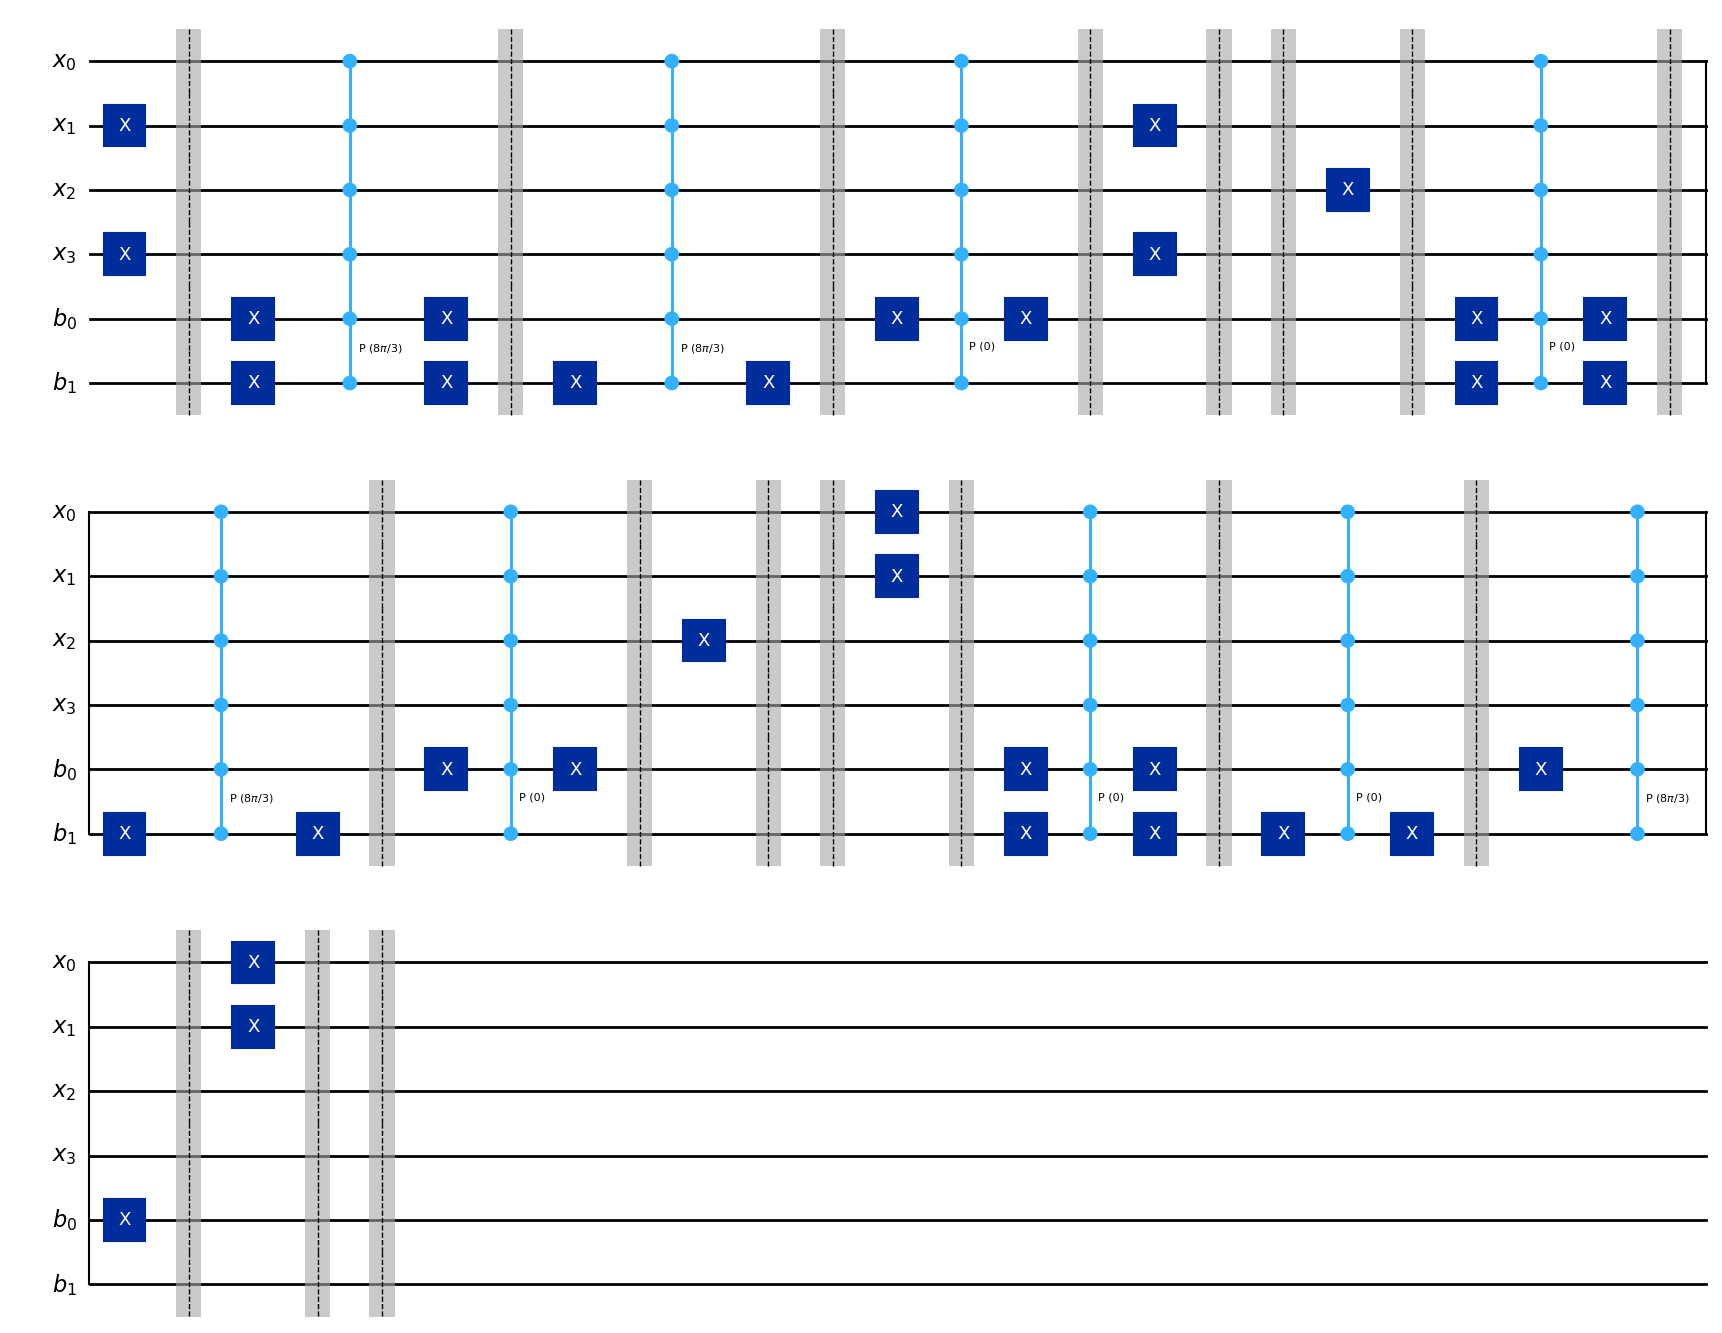

In [198]:
multi_oracle_example = multi_oracle_sketching_circuit(domain_size,codomain_size,multibitsamples[:3], len(multibitsamples)*np.pi)
multi_oracle_example.draw(output='mpl')

In [210]:
multibitsamples

array([[ 5.,  3.],
       [11.,  2.],
       [12.,  4.],
       [ 8.,  1.],
       [15.,  0.],
       [ 9.,  3.],
       [11.,  2.],
       [ 5.,  3.],
       [15.,  0.],
       [ 0.,  4.],
       [ 0.,  4.],
       [ 1.,  7.],
       [12.,  4.],
       [ 7.,  7.],
       [13.,  7.],
       [12.,  4.],
       [ 6.,  3.],
       [ 9.,  3.],
       [ 2.,  5.],
       [ 4.,  3.],
       [14.,  6.],
       [ 5.,  3.],
       [ 2.,  5.],
       [ 4.,  3.],
       [11.,  2.],
       [12.,  4.],
       [10.,  5.],
       [12.,  4.],
       [13.,  7.],
       [14.,  6.],
       [ 2.,  5.],
       [ 4.,  3.]])

In [222]:
N = domain_size
tval = N*np.pi

bit_length = int(math.ceil(math.log2(codomain_size))) 
num_qubits_x = int(math.ceil(math.log2(domain_size)))
num_qubits_b = int(math.ceil(math.log2(bit_length)))

quantum_register_x = QuantumRegister(num_qubits_x,name='x')
quantum_register_b = QuantumRegister(num_qubits_b,name='b')

multibitcirc = multi_oracle_sketching_circuit(domain_size, codomain_size, multibitsamples, tval)

counter = 0

for x in range(N):
    phase_shift = tval/len(multibitsamples) # t/M
    times_in_sample = len(np.where(multibitsamples[:,:1] == x)[0]) # number of times state 'x' appears in sample
    f_x = examplemultibit(x) #f(x)
    
    x_statevector = Statevector.from_int(x,2**num_qubits_x) # |x>
    
    for j in range(math.ceil(np.log2(codomain_size))): # length of b register
        b_statevector = Statevector.from_int(j,2**(num_qubits_b)) # |j>
        starting_statevector = b_statevector.tensor(x_statevector) #|x j>

        f_x_string = f'{f_x:0{3}b}'[::-1] #f(x) = f_2 f_1 f_0: reverse order for easier indexing
        f_x_j = int(f_x_string[j]) #f_j(x)

        desired_phase = phase_shift*times_in_sample*f_x_j # (times applied) (f_x_j)/M
        target_state = np.exp(desired_phase*1j)*starting_statevector

        psi = starting_statevector.evolve(multibitcirc)
        if np.sum(np.abs(psi.data - target_state.data)**2) > 1e-10:
            print(f'k = {k} failed')
            display('target = ',target_state.draw("latex"))
            display('our statevector =',psi.draw("latex"))
            counter += 1
if counter == 0:
    print('All tests passed!')


All tests passed!


## Sparse Oracle Sketching

Sparse Oracle: $A$ is matrix with row sparsity $s_r$ and column sparsity $s_c$, meaning that each row has at most $s_r$ non-zero elements and similarly for $s_c$. $\max (s_r,s_c)$ is denoted by $s$. There are 3 sparse oracles:
	$$
	\begin{alignedat}{2}
		O_A^{\text{ele}} &\colon | i \rangle | j \rangle | 0 \rangle_b &&\mapsto |i \rangle | j \rangle |A_{ij} \rangle \\
		O_A^{\text{ind,row}} &\colon | i \rangle | k \rangle &&\mapsto |i \rangle | j(i,k) \rangle \\
		O_A^{\text{ind,col}} &\colon | j \rangle | k \rangle &&\mapsto |j \rangle  | i(j,k) \rangle,
	\end{alignedat}
	$$
	where $j(i,k) \in [N]$ encoded as a length $n$ bitstring is the index of the column where the $k \in [s_r]$'th non-zero element in row $i$ appears, and $i(j,k)$ is the index of the row where the $k \in [s_c] $'th non-zero element in row $j$ appears.
		We begin with the implementation of $O_A^{\text{ele}}$.

Note that for large matrix dimension, we could simulate a sparse matrix by making each entry of the form $\rho_{ij} \xi_{ij}$, where $\rho_{ij}$ are i.i.d. Bernoulli random variables with parameter $\rho$ and $\xi_{ij}$ are i.i.d are distributed according to our favorite probability distribution. Then Chebyshev's inequality would give us a good upper bound on $s_c, s_r$ that is still a lot smaller than $N$. However, as we use $N = 8$, we instead fill entries by choosing $s_r$ entries in each row to be non-zero. We then enforce the constraint that there are at most $s_c$ non-zero entries in each column by uniformly randomly setting a non-zero entry to zero in each column until the constraint is satisfied.


In [180]:
def generate_random_sparse(matrix_dimension, bitlength, sparsity, seed=None):
    ''' generates a random matrix with specified dimension. Entries are in 
    {0,... 2^{bitlength} - 1} and sparsity is the maximum number of nonzero entries
    in each row'''
    np.random.seed(seed)

    sparse_matrix1 = np.zeros((matrix_dimension,matrix_dimension))

    row_sparsity = sparsity #proportion of nonzero entries in each row
    nonzero_entry_number = int(math.floor(row_sparsity*matrix_dimension))

    #add non-zero entries matrix
    row_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=1)
    col_nonzero_counts = np.count_nonzero(sparse_matrix1 , axis=0)

    for j in range(matrix_dimension):
        while row_nonzero_counts[j]  < nonzero_entry_number:
            sparse_matrix1[j][np.random.choice(np.arange(matrix_dimension))] = np.random.randint(2**bitlength)
            row_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=1)
    col_nonzero_counts = np.count_nonzero(sparse_matrix1 , axis=0)
    for k in range(matrix_dimension):
        while col_nonzero_counts[k]  > nonzero_entry_number: #delete entries that make column too dense
            sparse_matrix1[np.random.choice(np.arange(matrix_dimension))][k] = 0
            col_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=0)
    row_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=1)

    sparse_matrix1 = sparse_matrix1.astype(int)
    return sparse_matrix1

In [179]:
#implement data streaming process on sparse matrix
def sparse_element_stream(sparse_matrix,seednum=100):
    ''' Uniformly randomly picks an index (i,j) such that A_{ij} != 0
    and returns a single sample [i, j, A_{ij}]'''
    np.random.seed(seednum)
    support_size = np.count_nonzero(sparse_matrix)
    # for index, x in np.ndenumerate(sparse_matrix):
    #     print(index,x)
    support_indices = np.nonzero(sparse_matrix.astype(int))

    index = np.random.randint(0,support_size)
    sample=[int(support_indices[0][index]),int(support_indices[1][index]),int(sparse_matrix[support_indices[0][index],support_indices[1][index]])]
    return sample


In [178]:
stream = sparse_element_stream(example_sparse_matrix,seednum=np.random.randint(0,1000))
display(Markdown(rf'$A_{{{stream[0]+1},{stream[1]+1}}} = {stream[2]}$'))
if stream[2] == example_sparse_matrix[stream[0], stream[1]]:
    print('sample is correct')
else:
    print('sample is incorrect')

$A_{4,3} = 3$

sample is correct


### Constructing the Element Oracle

The element oracle 
$$
O_A^{\text{ele}}  | i \rangle | j \rangle | 0 \rangle_b \mapsto |i \rangle | j \rangle |A_{ij} \rangle 
$$
is constructed in a similar way to the sketching oracle for functions. If $A$ is an $2^n \times 2^n$ matrix with elements $A_{ij} \in \{ 0,1 \}^b$, then we have two $n$-qubit registers for the row index $i$ and column index $j$ respectively, and a $b$-bit register for the element $A_{ij}$. 

 We can consider our sample as $((i,j),A_{ij})$, where $(i,j)$ are such that $A_{ij} \neq 0$. Recall that before we had $t= N \pi$. Now, $t = K \pi$ where $K$ is the number of nonzero entries of our matrix. Then if we write the $a$-th bit of $A_{ij}$ as $(A_{ij})_{a}$, the sketching tells us to apply the gate:
$$
V_a(i,j) = \exp \left[ i \frac{\pi K}{M} (A_{ij})_{a} | i, j \rangle \langle i, j | \right]
$$
for each $a$ whenever we draw a sample $(i,j, A_{ij})$. This can be implemented as a multi-controlled phase gate, with control state $| i \rangle |j \rangle$ on the $i,j$ registers and target bit $a$ on the element register. Sketching then tells us that this approximates the phase oracle:
$$
U_a = \sum_{i,j} (-1)^{(A_{ij})_{a}} |i , j \rangle \langle i , j |.
$$
We can then use Hadamard gates on the element register to convert this from a phase oracle to an XOR oracle, so that the element register encodes the bits of $|A_{ij} \rangle$.

In [158]:
def element_oracle_gate(matrix, samples: int, startingseed=None, samplerelative=False, prints=False):
    ''' Element oracle for given sparse matrix with specified sample count.
    Sample count will be (number of nonzero entries)*(samples) if samplerelative=True'''

    if startingseed == None:
        startingseed = np.random.randint(1e8)

    num_qubits = required_qubits(matrix)
    element_bits = math.ceil(np.log2(np.max(matrix)))

    qr_row = QuantumRegister(num_qubits,name='q_row')
    qr_col = QuantumRegister(num_qubits,name='q_col')
    qr_entry = QuantumRegister(element_bits,name='q_entry')
    element_oracle_circuit = QuantumCircuit(qr_row,qr_col,qr_entry)

    K = np.count_nonzero(matrix) #size of sample space

    seednumber = startingseed

    sample_number=  samples

    if samplerelative==True:
        sample_number = sample_number*K

    #initialize |0> to |-> so that controlled phase marking yields |-> when undoing.
    element_oracle_circuit.x(qr_entry)
    element_oracle_circuit.h(qr_entry) 

    for m in range(sample_number):
        rsample = sparse_element_stream(matrix,seednum=seednumber) 
        seednumber += 1
        if prints == True:
            display(f'i = {rsample[0]} j = {rsample[1]} Aij = {rsample[2]}')
        for k in range(element_bits):

            row_bitstring = f'{rsample[0]:0{num_qubits}b}'
            col_bitstring = f'{rsample[1]:0{num_qubits}b}'
            element_bitstring = f'{rsample[2]:0{element_bits}b}'[::-1]

            index_bitstring = col_bitstring+row_bitstring #mcp control state reads right to left (big endian)
            #Apply random unitary V_a(i,j) for A_{i,j} bitwise on entry register

            bitint = int(element_bitstring[k])
            element_oracle_circuit.mcp(np.pi*K*bitint/sample_number,control_qubits=qr_row[:]+qr_col[:],target_qubit=qr_entry[k],ctrl_state= index_bitstring)

    element_oracle_circuit.h(qr_entry)
    element_oracle_circuit.x(qr_entry)

    return element_oracle_circuit

'i = 4 j = 6 Aij = 2'

'i = 5 j = 7 Aij = 1'

'i = 0 j = 0 Aij = 3'

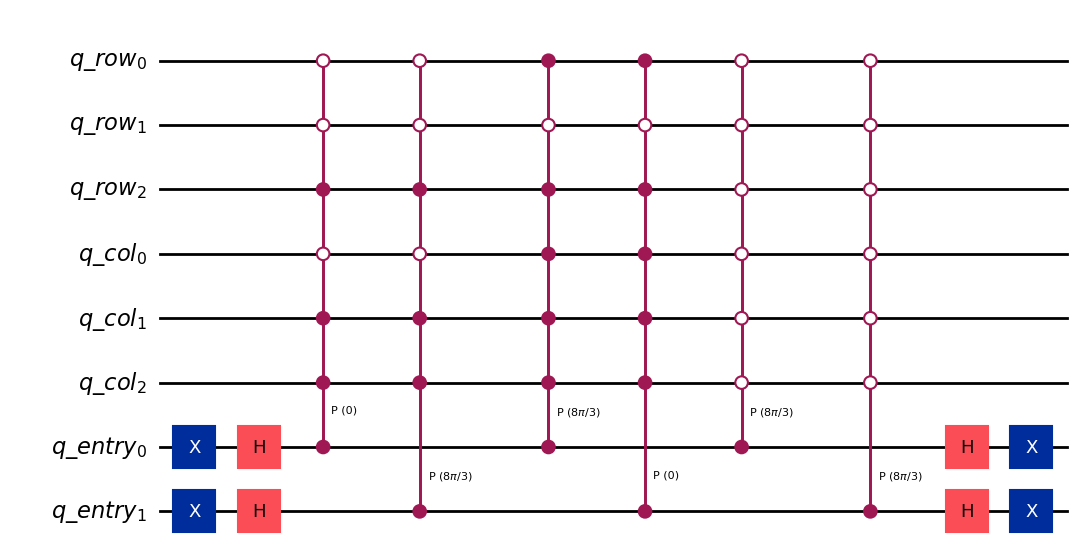

In [159]:
eleoracle = element_oracle_gate(sparse8,samples=3,startingseed=0,samplerelative=False, prints=True)
eleoracle.draw('mpl')

In [171]:
def guess_matrix(sparsematrix,samples=25,startingseed=0,samplerelative=False, rounding=None):
    
    matrix_dim = len(sparsematrix)
    num_qubits = int(np.log2(len(sparsematrix)))

    reconstructed_matrix = np.zeros((matrix_dim,matrix_dim))
    reconstructed_variance = np.zeros((matrix_dim,matrix_dim))
    reconstructed_probs = np.zeros((matrix_dim,matrix_dim))
    bitlength = math.ceil(np.log2(np.max(sparsematrix)+1))
    element_oracle_circuit = element_oracle_gate(sparsematrix,samples,startingseed,samplerelative=samplerelative)
    
    for i in range(2**num_qubits):
        for j in range(2**num_qubits):
            if sparsematrix[i][j] != 0:
                # display(f'i= {i} j= {j}')

                i_state = Statevector.from_int(i,2**num_qubits)
                j_state = Statevector.from_int(j,2**num_qubits)
                blank_entry = Statevector.from_int(0,2**bitlength)

                starting_state = blank_entry.tensor(j_state.tensor(i_state))
                # display('starting state=',starting_state.draw('latex'))

                psi= starting_state.evolve(element_oracle_circuit)
                # display('psi=',psi.draw('latex'))

                probs = psi.probabilities(range(2*num_qubits,2*num_qubits+bitlength))
                max_arg = np.argmax(probs)
                element_guess = max_arg

                expected_entry = (np.arange(len(probs)) *probs).sum()
                if rounding != None:
                    expected_entry = np.round(expected_entry,decimals=rounding)

                variance_entry = (probs * np.arange(len(probs))**2).sum() - expected_entry**2
                if rounding != None:
                    variance_entry = np.round(variance_entry,decimals=rounding) - expected_entry**2

                reconstructed_matrix[i][j] = expected_entry
                reconstructed_variance[i][j] = variance_entry
                reconstructed_probs[i][j] = psi.probabilities()[element_guess]
    return reconstructed_matrix, reconstructed_variance, reconstructed_probs    

In [172]:
guesses = guess_matrix(sparse8,samples=1000,startingseed=0,samplerelative=False,rounding=None)
print(f'True matrix is \n {sparse8}')
print(f'Expected guesses are \n {guesses[0]}')

True matrix is 
 [[3 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0]
 [0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 1]
 [0 0 3 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]]
Expected guesses are 
 [[2.92064746 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.96011592 0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         1.99495102
  0.         0.        ]
 [0.         0.         0.         0.         1.89940525 0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  1.96858316 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.97743227]
 [0.         0.         2.96978258 0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.99857945 0.         0.
  0.         0.        ]]


In [ ]:
sparsity = [1,3,5,7]

samples = np.arange(50,500,50)

sparsitymeanerrors = np.zeros((len(sparsity),len(samples)))
sparsityworsterrors = np.zeros((len(sparsity),len(samples)))

for k in range(len(sparsity)):
    sparsity = sparsity[k]
    testmatrix = generate_random_sparse(8,3,sparsity)
    supportsize = len(np.where(testmatrix !=0)[0])

    startingseed = np.random.randint(0,1000)
    for j in range(len(samples)):
        guess = guess_matrix(testmatrix,samples=samples[j],startingseed=startingseed)[2]
        
        errormatrix = np.abs(1-guess)
        meanerror = errormatrix.sum()/supportsize
        worst = np.max(errormatrix)
        sparsitymeanerrors[k][j] = meanerror
        sparsityworsterrors[k][j] = worst


Below is a line graph showing the probability of incorrectly measuring $A_{ij}$ for $8 \times 8$ test matrices of different sparsities, where the oracle circuit is computed using the specified number of samples. The mean probability of incorrect measurement and worst-case probability of incorrect measurement are computed over the set of non-zero entries of $A$, i.e.
$$
\begin{align*}
\text{Mean Probability} &= \frac{1}{|\mathcal{K}|} \sum_{(i,j) \in \mathcal{K}} (1 - |\langle A_{ij} | \psi \rangle|^{2}) \\
\text{Worst-case Probability} &= \max_{(i,j) \in \mathcal{K}} \left( 1 - |\langle A_{ij} | \psi \rangle|^{2} \right)
\end{align*}
$$
where $\mathcal{K} = \{(i,j) \in [N]^{2} : A_{ij} \neq 0\}$ is the set of non-zero entries of $A$, and $\psi$ is the state $O^{\text{ele}} | i \rangle | j \rangle | 0 \rangle$.


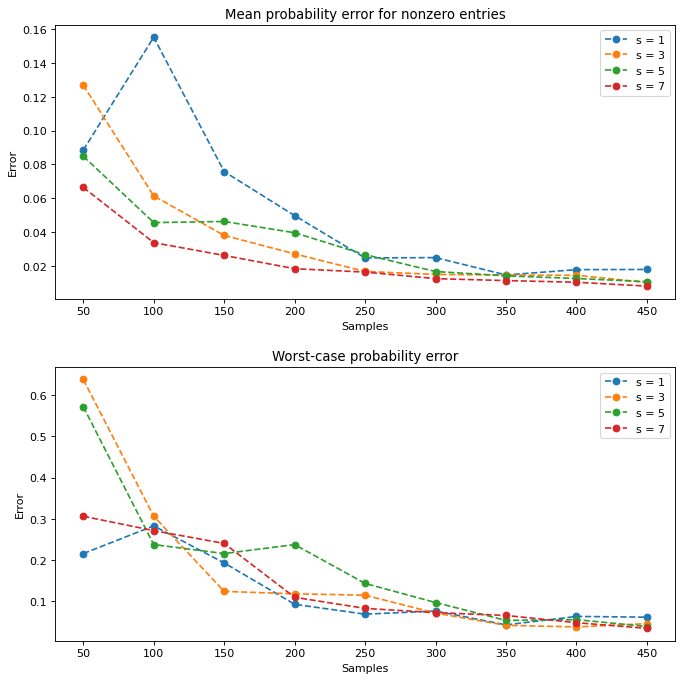

In [56]:
savedsparsitymeanerrors = np.load('./data/savedsparsitymeanerrors.npy')
savedsparsityworsterrors = np.load('./data/savedsparsityworsterrors.npy')
samples = np.arange(50,500,step=50)

plt.figure(figsize=(10, 10), dpi=80)
plt.subplot(211)

for m in range(4):
    plt.plot(samples,savedsparsitymeanerrors[m],label=f's = {np.arange(1,9,step=2)[m]}',marker='o',linestyle='--')
plt.title('Mean probability error for nonzero entries')
plt.xlabel('Samples')
plt.ylabel('Error')
plt.legend(loc='upper right')

plt.subplot(212)
for m in range(4):
    plt.plot(samples,savedsparsityworsterrors[m],label=f's = {np.arange(1,9,step=2)[m]}',marker='o',linestyle='--')
plt.title("Worst-case probability error")
plt.xlabel('Samples')
plt.ylabel('Error')

plt.subplots_adjust(hspace=0.25)
plt.legend(loc='upper right')

plt.show()

Here are some examples of entrywise expectation and variance for measurement of $A_{ij}$, computed using the statevector for the element oracle circuit. $K$ denotes the number of nonzero entries of $A$.

With $25K$ samples:
$$
\begin{align*}
\text{expected matrix} &=
\begin{pmatrix} 
0.0 & 1.992 & 0.0 & 1.992 & 3.0 & 0.0 & 0.0 & 2.988 \\
1.809 & 0.0 & 0.0 & 0.0 & 0.0 & 0.996 & 1.992 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 2.139 & 2.988 & 0.0 & 1.063 \\
1.93 & 0.0 & 0.905 & 0.0 & 0.0 & 1.729 & 0.0 & 0.0 \\
0.0 & 1.637 & 1.0 & 0.0 & 0.0 & 0.0 & 2.814 & 0.996 \\
0.0 & 0.0 & 0.0 & 0.996 & 1.809 & 0.0 & 3.0 & 0.0 \\
3.0 & 2.953 & 0.0 & 2.0 & 0.0 & 0.0 & 0.0 & 0.864 \\
0.0 & 1.809 & 2.714 & 0.0 & 2.593 & 0.768 & 0.0 & 0.0 \\
\end{pmatrix} \\
& \\
\text{variance matrix} &=
\begin{pmatrix} 
0.0 & 0.016 & 0.0 & 0.016 & 0.0 & 0.0 & 0.0 & 0.02 \\
0.345 & 0.0 & 0.0 & 0.0 & 0.0 & 0.004 & 0.016 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 1.023 & 0.02 & 0.0 & 0.996 \\
0.136 & 0.0 & 0.086 & 0.0 & 0.0 & 0.469 & 0.0 & 0.0 \\
0.0 & 0.594 & 0.0 & 0.0 & 0.0 & 0.0 & 0.29 & 0.004 \\
0.0 & 0.0 & 0.0 & 0.004 & 0.345 & 0.0 & 0.0 & 0.0 \\
0.0 & 0.077 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.117 \\
0.0 & 0.345 & 0.432 & 0.0 & 0.586 & 0.178 & 0.0 & 0.0 \\
\end{pmatrix}
\end{align*}
$$


With $100K$ samples:
$$
\begin{align*}
\text{expected matrix} &=
\begin{pmatrix} 
0.0 & 1.941 & 0.0 & 1.891 & 2.993 & 0.0 & 0.0 & 2.993 \\
1.96 & 0.0 & 0.0 & 0.0 & 0.0 & 0.93 & 1.93 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 2.895 & 2.94 & 0.0 & 1.988 \\
1.982 & 0.0 & 0.998 & 0.0 & 0.0 & 1.988 & 0.0 & 0.0 \\
0.0 & 1.844 & 0.97 & 0.0 & 0.0 & 0.0 & 2.953 & 0.998 \\
0.0 & 0.0 & 0.0 & 0.991 & 1.988 & 0.0 & 2.988 & 0.0 \\
2.999 & 2.741 & 0.0 & 2.0 & 0.0 & 0.0 & 0.0 & 0.998 \\
0.0 & 1.976 & 2.911 & 0.0 & 2.561 & 0.965 & 0.0 & 0.0 \\
\end{pmatrix} \\
& \\
\text{variance matrix} &=
\begin{pmatrix} 
0.0 & 0.115 & 0.0 & 0.206 & 0.011 & 0.0 & 0.0 & 0.011 \\
0.078 & 0.0 & 0.0 & 0.0 & 0.0 & 0.065 & 0.136 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 0.169 & 0.097 & 0.0 & 0.024 \\
0.035 & 0.0 & 0.002 & 0.0 & 0.0 & 0.024 & 0.0 & 0.0 \\
0.0 & 0.287 & 0.029 & 0.0 & 0.0 & 0.0 & 0.077 & 0.002 \\
0.0 & 0.0 & 0.0 & 0.009 & 0.024 & 0.0 & 0.02 & 0.0 \\
0.001 & 0.395 & 0.0 & 0.001 & 0.0 & 0.0 & 0.0 & 0.002 \\
0.0 & 0.048 & 0.143 & 0.0 & 0.625 & 0.034 & 0.0 & 0.0 \\
\end{pmatrix}
\end{align*}
$$


With $1000K$ samples:
$$
\begin{align*}
\text{expected matrix} &=
 \begin{pmatrix} 
0.0 & 1.999 & 0.0 & 1.996 & 2.973 & 0.0 & 0.0 & 3.0 \\
2.0 & 0.0 & 0.0 & 0.0 & 0.0 & 1.0 & 2.0 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 2.984 & 3.0 & 0.0 & 1.99 \\
1.997 & 0.0 & 1.0 & 0.0 & 0.0 & 1.995 & 0.0 & 0.0 \\
0.0 & 1.982 & 1.0 & 0.0 & 0.0 & 0.0 & 2.973 & 0.999 \\
0.0 & 0.0 & 0.0 & 0.999 & 2.0 & 0.0 & 2.999 & 0.0 \\
2.996 & 2.992 & 0.0 & 1.991 & 0.0 & 0.0 & 0.0 & 1.0 \\
0.0 & 1.996 & 2.989 & 0.0 & 2.999 & 0.995 & 0.0 & 0.0 \\
\end{pmatrix}\\
& \\
\text{variance matrix} &=
\begin{pmatrix} 
0.0 & 0.002 & 0.0 & 0.007 & 0.044 & 0.0 & 0.0 & 0.0 \\
0.001 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 0.027 & 0.0 & 0.0 & 0.019 \\
0.006 & 0.0 & 0.0 & 0.0 & 0.0 & 0.01 & 0.0 & 0.0 \\
0.0 & 0.035 & 0.0 & 0.0 & 0.0 & 0.0 & 0.044 & 0.001 \\
0.0 & 0.0 & 0.0 & 0.001 & 0.0 & 0.0 & 0.002 & 0.0 \\
0.007 & 0.013 & 0.0 & 0.018 & 0.0 & 0.0 & 0.0 & 0.0 \\
0.0 & 0.008 & 0.019 & 0.0 & 0.002 & 0.005 & 0.0 & 0.0 \\
\end{pmatrix}
\end{align*}
$$

On the other hand:
$$
\text{true matrix} =
\begin{pmatrix} 
0 & 2 & 0 & 2 & 3 & 0 & 0 & 3 \\
2 & 0 & 0 & 0 & 0 & 1 & 2 & 0 \\
0 & 0 & 0 & 0 & 3 & 3 & 0 & 2 \\
2 & 0 & 1 & 0 & 0 & 2 & 0 & 0 \\
0 & 2 & 1 & 0 & 0 & 0 & 3 & 1 \\
0 & 0 & 0 & 1 & 2 & 0 & 3 & 0 \\
3 & 3 & 0 & 2 & 0 & 0 & 0 & 1 \\
0 & 2 & 3 & 0 & 3 & 1 & 0 & 0 \\
\end{pmatrix}
$$

We also test how close the expected value of an entry measurement is to the correct matrix for $N = 8$ and $s_r = 2$

In [173]:
testmatrix = generate_random_sparse(8,2,2/8)
print(f'Matrix dimension = {len(testmatrix)} x {len(testmatrix)}')
print(f'Nonzero entries = {support}')

sample_counts = 100,1000,10000
for sample_count in sample_counts:
    testmatrix_guess = guess_matrix(testmatrix,sample_count)[0]
    error = np.zeros((8,8))
    for i in range(len(testmatrix)):
        for j in range(len(testmatrix)):
            if testmatrix[i][j] != 0:
                error[i][j] = np.abs(testmatrix[i][j] - testmatrix_guess[i][j])/testmatrix[i][j]
    support = np.count_nonzero(testmatrix)
    mean_error = np.sum(error)/support
    max_error = np.max(error)
    print(f'Sample count = {sample_count}')
    print(f'Mean relative error = {mean_error}')
    print(f'Max relative error = {max_error}')

Matrix dimension = 8 x 8
Nonzero entries = 11
Sample count = 100
Mean relative error = 0.2685929770181221
Max relative error = 0.9842915805643483
Sample count = 1000
Mean relative error = 0.033205822341928544
Max relative error = 0.13124344133881272
Sample count = 10000
Mean relative error = 0.0024320614110609237
Max relative error = 0.006967096958355808


### Constructing the Row and Column Oracles

The constructions of $O_A^{\text{ind,row}}$ and $O_A^{\text{ind,col}}$ are entirely analogous to each other after swapping the roles of rows and column indices. Therefore we only go into detail on $O_A^{\text{ind,row}}$. The construction requires the following intermediate Oracle:
$$
O_c \colon | i \rangle | k \rangle | l \rangle |0 \rangle \mapsto |i \rangle | k \rangle | l \rangle | \mathbf{1}\left\{ C(i,l) < k \right\} \rangle, \quad i,l \in \{0,1\}^n, k \in \{1,\dots,s_r\},
$$
where 
$$
C(i,l) = \left| \left\{ j \colon A_{ij} \neq 0, j < l \right\}  \right|.
$$
$C(i,l)$ tells us how many non-zero entries are in the $i$'th row of $A$ before the $l$'th column.
We remark that the sparse oracles are most suited to the cases where $s_r \ll 2^n$, as then fewer qubits are required to store $| k \rangle$. In the paper https://arxiv.org/pdf/2604.07639, the authors construct $O_c$ by first constructing the 'cumulative counter unitary' $U_C$, defined by 
$$
U_C \colon | i,k,l \rangle \mapsto e^{i \theta(i,k,l)} | i,k,l \rangle, \quad i,,l \in \{0,1\}^n, k \in \{1,\dots,s_r\},
$$
where they define 
$$
\theta(i,k,l) = \frac{\pi}{2(s_r +1/2)} \left( C(i,l)- k +\frac{1}{2} \right).
$$
Then, quantum singular value transformation applies an approximation of the sign function to send positive phases $\theta(i,k,l)$ to $0$ and negative phases to $\pi$. 
<!-- For us, we shall compute each $C(i,l)$ in advance and use a helper comparator circuit instead. Note that the method from the paper is preferred, as it can be implemented using Oracle sketching of a Boolean function, therefore removing the need to store all of the $C(i,l)$ values. -->

For the QSVT step, we use the file `sign_function_qsvt.py` which contains the functions `get_sign_phases(degree, delta, max_scale)` and `qiskitCircuit_to_QSVTgate(circuit,phases)`. The former returns a tuple containing phase angles for an approximation of the sign function of the specified degree using $\text{erf}(\delta x)$ using the `pyqsp` package, and the scale $\leq 1$ that `sign(x)` was potentially scaled down by to in order to ensure $|P(x)| \leq 1$ on $[0,1]$. The latter returns a circuit that implements the QSVT step to a given $(n+1)$ qubit circuit encoding a Hermitian matrix on its first $n$ qubits when the ancilla qubit is in the $|0\rangle$ state. See the corresponding file `sign_function_qsvt.ipynb` for more details.

#### Cumulative Count Unitary ####

We (approximately) construct $U_c$ as detailed in Lemma D.20 of https://arxiv.org/pdf/2604.07639. This is actually just a case of the Boolean function sketching Oracle, except for each sample $(i,j,A_{ij})$ one must apply
$$
V(i,j) = \exp \left[\frac{i}{M}\frac{\pi K}{2(s_r+1/2)}\sum_{a \colon (i,j) \in S_a} |a \rangle \langle a | \right],
$$
where 
$$
S_a = \left\{(i,j): A_{ij} \neq 0, j<l\right\}
$$
for $a = (i,k,l)$.
In other words, given $(i,j)$ from sample we must find apply the projector $|a \rangle \langle a |$ for all $a = (i,k,l)$ such that $j<l$. Note that $k$ does not appear in the definition of $S_a$, so we should just have our control on the row $i$ and index $l$ registers only. We use `IntegerComparator` on the $l$ register with a single ancilla bit here for simplicity, then our control state is $|i \rangle ... |1 \rangle_a$. We clean the ancilla bit after each use. Note that this is possible because we find the value of $j$ from a sample as opposed to it being encoded in our quantum state, so we can use this as a value for a comparator gate.

Applications of $V(i,j)$ for all samples approximate the phase shift:
$$
\frac{C(i,l) \pi}{2(s_r +1/2)},
$$
so we then have to apply the fixed offset gate
$$
U_o: |i, k, l \rangle \to e^{-i\frac{\pi}{2(s_r+1/2)}(k-1/2)} | i, k, l \rangle,
$$
in order to yield $U_c$ as desired.

In [21]:
def rcumulative_count_unitary(matrix: ArrayLike, samplenum:int=25, startingseed:int=None, samplerelative:bool=False, row_sparsity:int=None) -> QuantumCircuit:
    ''' Implements row Cumulative Count Unitary for given matrix'''
    
    if row_sparsity is None:
        row_sparsity = np.max(np.count_nonzero(matrix, axis=1))
    
    num_qubits = math.ceil(np.log2(len(matrix)))
    sparse_bits = math.ceil(np.log2(row_sparsity+1))

    qr_row = QuantumRegister(num_qubits,name='q_i')
    qr_sparse = QuantumRegister(sparse_bits,name='q_k')
    qr_l = QuantumRegister(num_qubits,name='q_l')
    ar = AncillaRegister(1,name='a') #For the Comparator
    wr = AncillaRegister(num_qubits-1,name='w') #For the Comparator working register (comparing to qr_sparse, so need same number of ancillas to compare)

    rcumulative_unitary_circuit = QuantumCircuit(qr_row,qr_sparse,qr_l,ar,wr)

    K = np.count_nonzero(matrix) #size of sample space

    if samplerelative == True:
        sample_number = int(K*samplenum)
    else:
        sample_number = samplenum

    phasedenom = 2*(row_sparsity+0.5) # constant factor used in all phase gates
    phase_shift = np.pi*K/(sample_number*phasedenom) #constant factor used in sampled mcp gates
    
    if startingseed == None:
        startingseed = np.random.randint(1e8)

    seednumber = startingseed

    for m in range(sample_number):
        rsample = sparse_element_stream(matrix,seednum=seednumber) 
        seednumber += 1
        display(f'sample: ({rsample[0]},{rsample[1]})')
        
        comparator_value = rsample[1]

        if comparator_value != 2**num_qubits-1: #otherwise impossible to have l > j
            comparator_circuit = IntegerComparator(num_state_qubits=num_qubits,value=comparator_value+1,geq=True).to_gate() #ancilla stores l > j
            comparator_circuit.name = rf'$l > {rsample[1]}$'
            comparator_inverse = comparator_circuit.inverse()
            comparator_inverse.name = rf'$l > {rsample[1]}^{{\dagger}}$'

            rcumulative_unitary_circuit.compose(comparator_circuit,qr_l[:]+ar[:]+wr[:],inplace=True) 
            rcumulative_unitary_circuit.mcp(phase_shift,control_qubits=qr_row[:],target_qubit=ar[0],ctrl_state= rsample[0]) #Uses ancilla to implement phase shift on all appropriate |a>
            rcumulative_unitary_circuit.compose(comparator_inverse,qr_l[:]+ar[:]+wr[:],inplace=True) # clean all ancillas!

    #Now implement offset gate U_o to get U_c
    offsetfactor = -np.pi/phasedenom 

    rcumulative_unitary_circuit.x(ar)
    rcumulative_unitary_circuit.p(offsetfactor*-0.5,ar[0]) #-1/2 part of offset gate
    rcumulative_unitary_circuit.x(ar)

    for b in range(sparse_bits):
        rcumulative_unitary_circuit.p(offsetfactor*2**b,qr_sparse[b]) # k part of offset gate

    return rcumulative_unitary_circuit

We can see from the circuit diagram below that our multi-control phase gates are applied to $| i , k , l \rangle$ where $i$ comes from our sample, and $l$ is such that $l > j$ from our sample.

'sample: (2,5)'

'sample: (1,1)'

'sample: (6,2)'

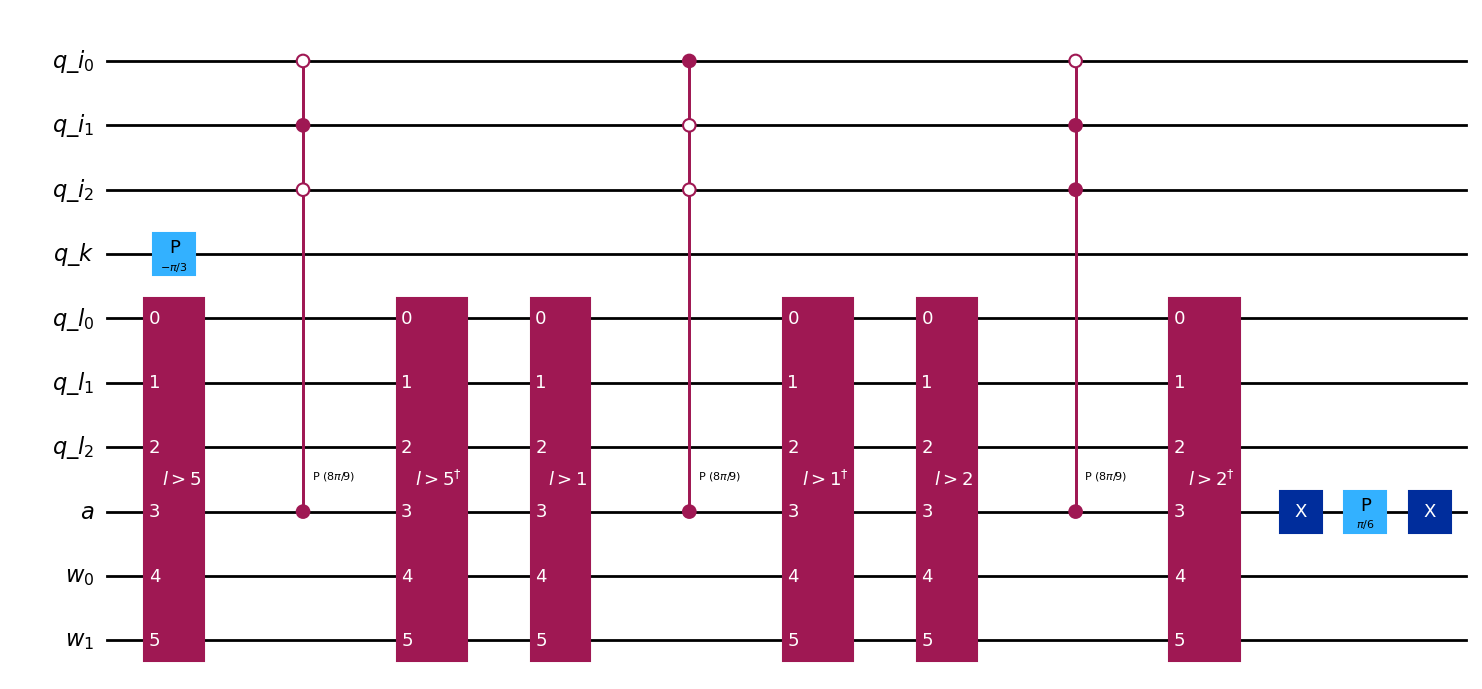

In [25]:
rcumulative_count_unitary(sparse8, samplenum=3).draw(output="mpl")

While it goes against the memory-saving of the streaming process described in the paper, we have a function for generating a list of samples for a given matrix. We then have the cumulative count unitary implemented as a diagonal matrix from the entire sample list. This allows for quicker computation than the multi-phase gate and integer comparator circuit, and therefore we use it later in order to be able to run demos faster. We emphasize that the construction of $U_c$ using sample streaming saves one in memory costs of storing the full list of samples. However, for the purposes of simulating, pre-computing the total phase shift from all samples before applying a single gate is a lot more efficient, and we do not use more memory as we are storing our entire matrix in memory anyway, as opposed to it being an unknown matrix that we can sample from.

In [24]:
def quick_rcumulative_count_unitary(matrix, sample_list, row_sparsity=None):
    ''' Computes row Cumulative Count Unitary for given matrix and sample list
    as a diagonal gate to bypass integer comparator'''

    if row_sparsity == None:
        row_sparsity = rowsparsity(matrix)

    K = np.count_nonzero(matrix)

    num_qubits = required_qubits(matrix)
    sparse_bits = required_sparse_bits(matrix)
    
    total_bits = 2*num_qubits + sparse_bits
   
    phasedenom = 2*(row_sparsity+0.5) # constant factor used in all phase gates

    phase_shift = np.pi*K/(len(sample_list)*phasedenom) #constant factor K pi/M 2(s_r+1/2) used in sampled gates

    phase_list = 0.5*np.pi/phasedenom * np.ones(2**total_bits) # non-k part of U_o

    for k in range(1,row_sparsity+1): # k starts at 1
        k_val_index = k*2**(num_qubits) # translates k to its index in statevector/ matrix: past the i register

        for i in range(2**num_qubits):
            for l in range(2**num_qubits):
                phase_list[i + k_val_index + l*2**(num_qubits+sparse_bits)] += -np.pi*k/phasedenom # k part of U_o applied to |i,k,l>
        
        for m in range(len(sample_list)):
            i_index = sample_list[m][0]
            j_index = sample_list[m][1]

            for l in range(j_index + 1,2**num_qubits): # l > j
                l_val_index = l*2**(num_qubits + sparse_bits) # l is after the i and k registers
                phase_list[l_val_index + k_val_index + i_index] += phase_shift # apply to all such l and any k

    diag_entries = np.exp(1j*phase_list)
    phase_diag = DiagonalGate(diag_entries)
    phase_diag.label = r'$U_c$'

    return phase_diag

In [ ]:
def get_samples(matrix: ArrayLike, sample_size:int=10, seednumber:int=None, samplerelative:bool=False) -> list[list[int]]:
    ''' Generates samples of a matrix for use in phase oracles'''
    if samplerelative == True:
        K = np.count_nonzero(matrix) #size of sample space
        sample_size = int(K*sample_size)
    
    if seednumber == None:
        seednumber = np.random.randint(1e8)

    sample_list = []

    seed = seednumber

    for _ in range(sample_size):
        sample_list.append(sparse_element_stream(matrix,seednum=seed))
        seed += 1

    return sample_list

The following two functions assist us with verifying the accuracy of the sketching procedure, by computing the quantity $C(i,l)$ and $\theta(i,k,l)$

In [26]:
def cumulative_count(sparse_matrix): #for testing whether Cumulative Count Unitary/ Oracle is accurate
    '''Returns array containing all C(i,l) as defined above.'''
    cumulative_count = np.zeros_like(sparse_matrix)
    for i in range(len(sparse_matrix)):
        running_total = 0
        for l in range(1,len(sparse_matrix)): #C(i,0) == 0
            if sparse_matrix[i,l-1] != 0:
                running_total +=1
            cumulative_count[i,l] = running_total
    return cumulative_count

In [27]:
def find_desired_phase(matrix,i,k,l):
    ''' Returns the desired phase theta(i,k,l) for the given matrix, i,k,l
    given by pi*(C(i,l) - k + 1/2) / 2(s_r+1/2)'''
    row_sparsity = rowsparsity(matrix)
    Cil = cumulative_count(matrix)[i][l]
    return np.pi*(Cil - k +0.5)/(2*(row_sparsity+0.5))

We write functions `quick_unitary_test` `rcumulative_count_unitary_test` and for verifying the accuracy of the phase oracles, computing the 2-norm error and error in phase for each basis state $|i\rangle |k\rangle |l\rangle |0\rangle$.

In [121]:
matrix = sparse4
samples = get_samples(matrix,100, seednumber = 10, samplerelative = True)
test = quick_unitary_test(matrix,samples)

All tests for cumulative count Unitary passed for test matrix 
 [[3 0 0 0]
 [0 0 0 3]
 [0 0 1 0]
 [0 3 0 0]] 

    average 2-norm error: 0.000191893692161646 
 max 2-norm error: 0.0009868792685368767 
 
    average angle error: 0.006544984694978776 
 max angle error: 0.03141592653589781
    


We demonstrate the difference in speeds between `rcumulative_count_unitary` and `quick_rcumulative_count_unitary` when we have many samples.

In [98]:
%%timeit -r 1 -n 1
matrix = dense4
samples = get_samples(matrix,150, seednumber = 10, samplerelative = True)
test = quick_unitary_test(matrix,samples)

All tests for cumulative count Unitary passed for test matrix 
 [[2 2 3 0]
 [3 2 0 1]
 [0 1 2 2]
 [3 0 3 1]] 

    average 2-norm error: 0.0011718324989107326 
 max 2-norm error: 0.005154149454332768 
 
    average angle error: 0.02374894446463775 
 max angle error: 0.07180783208205821
    
210 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [99]:
%%timeit -r 1 -n 1
matrix = dense4
test = rcumulative_count_unitary_test(matrix, samplenum=150, samplerelative=True, startingseed=10)

All tests for cumulative count Unitary passed for test matrix 
 [[2 2 3 0]
 [3 2 0 1]
 [0 1 2 2]
 [3 0 3 1]] 

    average 2-norm error: 0.0011718324989105566 
 max 2-norm error: 0.005154149454331297 
 
    average angle error: 0.02374894446463653 
 max angle error: 0.07180783208205033
    
1min 15s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


This justifies our use of the `DiagonalGate` circuit, due to the very noticeable speedup in the time it takes to build the circuit and evolve all basis states of interest. We also see from the errors that the end result is no more error-prone in the `DiagonalGate` circuit than the one using the comparator. However, the latter was also instructive in demonstrating how one does not need to store the full list of samples beforehand in order to implement the Cumulative Counter Unitary.

We now demonstrate with $8 \times 8$ matrice. We see that the average errors remain similar, but the maximum error increases, due to there being more non-zero entries. We also see an approximate doubling in runtime when going from a $4 \times 4$ matrix to an $8 \times 8$ matrix with $r_s=1$, and then an approximate $5$-fold increase when increase $r_2$ to $3$..

In [100]:
%%timeit -r 1 -n 1
matrix = sparse8
samples = get_samples(matrix,150, seednumber = 0, samplerelative = True)
test = quick_unitary_test(matrix,samples)

All tests for cumulative count Unitary passed for test matrix 
 [[3 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0]
 [0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 1]
 [0 0 3 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]] 

    average 2-norm error: 0.003105512575459952 
 max 2-norm error: 0.01946386251685925 
 
    average angle error: 0.03250675731839431 
 max angle error: 0.1396263401595459
    
452 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [97]:
%%timeit -r 1 -n 1
matrix = mid8
samples = get_samples(matrix,150, seednumber = 0, samplerelative = True)
test = quick_unitary_test(matrix,samples)

All tests for cumulative count Unitary passed for test matrix 
 [[3 0 0 0 3 3 0 0]
 [3 0 0 0 0 3 0 1]
 [3 0 1 0 0 0 3 0]
 [0 0 1 2 0 0 2 0]
 [0 3 0 0 0 0 1 2]
 [0 1 3 2 0 0 0 0]
 [0 0 0 0 1 1 0 3]
 [0 3 0 2 3 0 0 0]] 

    average 2-norm error: 0.0017511900316803666 
 max 2-norm error: 0.012912800950704057 
 
    average angle error: 0.030574428503686506 
 max angle error: 0.11369573412992295
    
2.45 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


From here on out we only show code for the quicker versions of each intermediate circuit needed to construct $O^{ind,row}_A$ as the code is almost identical, but the file `oracle_function.py` contains the code for the sample streaming approach as well.

#### Block encoding of Cumulative Count Unitary ####

Now we must construct the block encoding as in https://arxiv.org/pdf/2604.07639, proof of Lemma D.21. the procedure is to take the cumulative unitary $U_c$ and construct a controlled version $c_a U_c$ on an ancilla bit $a$. The one constructs 
$$
W_c = S_a X_a H_a (c_a U_c^{\dagger}) X_a (c_a U_c) H_a,
$$
where $S = \begin{pmatrix} -i & 0 \\ 0 & 1 \end{pmatrix}$ and all single-qubit gates and controls act on $a$.
$W_c$ is a block encoding of $\sum_{i,k,l} \sin(\theta(i,k,l)) | i,k,l \rangle \langle i,k,l |$ on the state $|0 \rangle_a$. Once we have this, we can use our QSVT function to send $W_c$ to $\text{sign}(W_C)$, which encodes $\sum_{i,k,l} \left[ \mathbb{1}_{C(i,l) < k}  \right] | i,k,l \rangle \langle i,k,l |$ when the ancilla bit is in the state $|0 \rangle_a$.

In [132]:
def rcumulative_encoding_quick(matrix: ArrayLike, sample_list: list[list[int]], row_sparsity:int=None) -> QuantumCircuit:
    '''Takes U_c to W_c for specified matrix. Accepts pre-prepared list of samples'''
    
    if row_sparsity is None:
        row_sparsity = np.max(np.count_nonzero(matrix, axis=1))
    
    num_qubits = required_qubits(matrix)
    sparse_bits = required_sparse_bits(matrix)

    qr_row = QuantumRegister(num_qubits,name='q_i')
    qr_sparse = QuantumRegister(sparse_bits,name='q_k')
    qr_l = QuantumRegister(num_qubits,name='q_l')
    encoding_ancilla = AncillaRegister(1,name='a') #Ancilla for encoding
    
    encoder_circuit = QuantumCircuit(qr_row,qr_sparse,qr_l,encoding_ancilla)

    cumulative_unitary_gate = quick_rcumulative_count_unitary(matrix, sample_list, row_sparsity=None)
    cumulative_unitary_gate.name = r'$U_c$'
    controlled_UC = cumulative_unitary_gate.control(1)
    controlled_adj = cumulative_unitary_gate.inverse().control(1)
    
    encoder_circuit.h(encoding_ancilla)
    encoder_circuit.compose(controlled_UC,encoding_ancilla[:]+qr_row[:]+qr_sparse[:]+qr_l[:],inplace=True)
    encoder_circuit.x(encoding_ancilla)

    encoder_circuit.compose(controlled_adj,encoding_ancilla[:]+qr_row[:]+qr_sparse[:]+qr_l[:],inplace=True)
    encoder_circuit.h(encoding_ancilla)
    
    encoder_circuit.p(3*np.pi/2,encoding_ancilla) # S = X P(3pi/2) X so omitted an X from the W_c formula
    encoder_circuit.x(encoding_ancilla)
    
    return encoder_circuit

Circuit for $4 \times 4$ matrix and $s_r = 1$ (version with ancillas for Comparator):

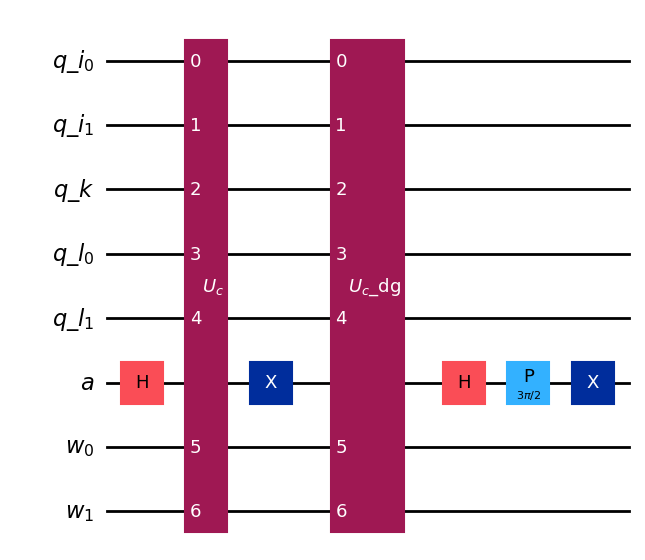

In [134]:
rcumulative_unitary_encoding(sparse4).draw('mpl')

As we see below, with sufficient sample count, the encoding of $\sum_{i,k,l} \sin \theta(i,k,l) |i,k,l \rangle \langle i,k, l |$ becomes very accurate for the majority of basis states. Recall that we just need our approximation to be close enough so that it falls within a region where our chosen approximation of $\text{sign}(x)$ is also accurate. 

In [147]:
sample_list = get_samples(sparse4,100,seednumber=10,samplerelative=True)
test = quick_encoding_check(sparse4,sample_list)

sample_list = get_samples(sparse8,100,seednumber=10,samplerelative=True)
test = quick_encoding_check(sparse8,sample_list)

All tests for cumulative count block encoder passed for test matrix 
 [[3 0 0 0]
 [0 0 0 3]
 [0 0 1 0]
 [0 3 0 0]] 

    average 2-norm error: 0.0001464452016322436 
 max 2-norm error: 0.0007534605092739506
    
All tests for cumulative count block encoder passed for test matrix 
 [[3 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0]
 [0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 1]
 [0 0 3 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]] 

    average 2-norm error: 0.004743414546012573 
 max 2-norm error: 0.022930424852306446
    


#### QSVT step

Now we test the transformed version of $W_c$, $P_{QSVT}(W_c)$, which should yield the phase Oracle 
$$
V_c \colon |i \rangle |k \rangle |l \rangle \to (-1)^{\mathbb{1}(C(i,k) < l)} |i \rangle |k \rangle |l \rangle
$$
Note that computation time and accuracy start to become an issue here when simulating classically: The QSVT circuit requires interleaving queries of the encoded cumulative count oracle, a number of times equal to the degree
of the polynomial approximation to the sign function. Combine this with the depth of $U_c$ increasing linearly with sample size, and it's difficult to get a good tradeoff between accuracy and computation time. Because of this, we switch to a $4 \times 4$ matrix for our toy example, shown below.

Below we show a visualization of the approximation to $\text{sign}(x)$ by a polynomial of specified degree approximating $\text{erf}(\delta x)$. Note that QSVT requires $|P(x)| \leq 1$ for all $x \in [-1,1]$, so the `max_scale` parameter scales down $\text{sign}(x)$ and is set to a number less than 1 in order to ensure this, due to the fact that the approximation will oscillate both above and below the true value of $\text{sign}(x)$. We then define a function that applies QSVT with the sign function on the Cumulative Count Unitary of the input matrix with specified degree, delta, and max_scale.

[pyqsp.poly.PolySign] degree=11, delta=5
[PolyTaylorSeries] (Cheb) max 0.9448514065702635 is at -0.7207631847685815: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.013684175793853276 in the domain [-1, 1] using degree 11


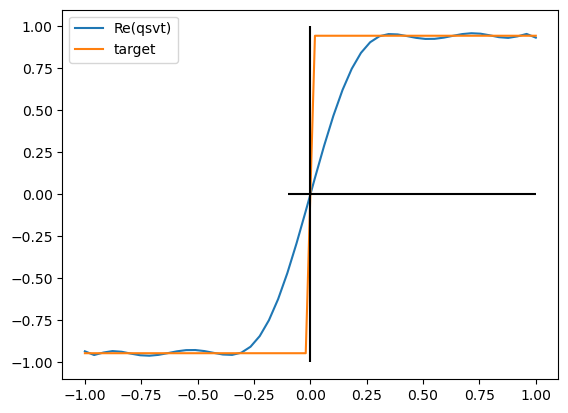

In [149]:
degree = 11
delta = 5
max_scale = 0.96
phases, scale = get_sign_phases(degree=degree,delta=delta,max_scale=max_scale)
check_sign_approx(phases,scale)

[pyqsp.poly.PolySign] degree=7, delta=4
[PolyTaylorSeries] (Cheb) max 0.9230881650476811 is at -0.4701136862309469: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.02819388696103535 in the domain [-1, 1] using degree 7


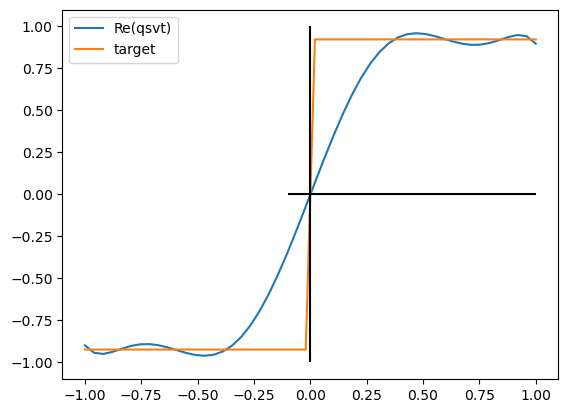

In [173]:
degree = 7
delta = 4
max_scale = 0.96
phases, scale = get_sign_phases(degree=degree,delta=delta,max_scale=max_scale)
check_sign_approx(phases,scale)

The function `get_sign_phases` gives us the sequence of phases $\{ \phi_m \}_{m=1}^d$ to apply QSVT.

In [150]:
get_sign_phases(degree=11, delta=5, max_scale= 0.96)

[pyqsp.poly.PolySign] degree=11, delta=5
[PolyTaylorSeries] (Cheb) max 0.9448514065702635 is at -0.7207631847685815: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.013684175793853276 in the domain [-1, 1] using degree 11


(array([-3.96980311,  1.6362962 ,  1.46503821,  1.74996006,  1.23678117,
         2.4106887 ,  2.4106887 ,  1.23678117,  1.74996006,  1.46503821,
         1.6362962 , -0.82821046]),
 np.float64(0.9448514065702635))

Now we construct the QSVT circuit by alternating between applications of $W_c$ and the projector phase gates $\Pi_{\phi_m}$:

In [153]:
def rcount_qsvt_quick(matrix,sample_list, degree=31, delta=11, max_scale=0.98, row_sparsity=None):
    ''' Applies sign function QSVT to block encoding of Cumulative Count Unitary
    corresponding to input matrix, provided list of samples'''
    if row_sparsity is None:
        row_sparsity = np.max(np.count_nonzero(matrix, axis=1))

    qsvt_phases, scale = get_sign_phases(degree=degree,delta=delta,max_scale=max_scale)
    readjust_angle = np.arccos(scale) #shift answers by this global scale 

    encoding_circuit = rcumulative_encoding_quick(matrix, sample_list = sample_list, row_sparsity=row_sparsity)
    encoding_circuit.name = r'$W_c$'
    
    qsvt_circuit = qiskitCircuit_to_QSVTCircuit(encoding_circuit,phases=qsvt_phases)
    return qsvt_circuit

[pyqsp.poly.PolySign] degree=3, delta=15
[PolyTaylorSeries] (Cheb) max 0.7871349106434548 is at -0.6911374056775529: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.19446611566816896 in the domain [-1, 1] using degree 3


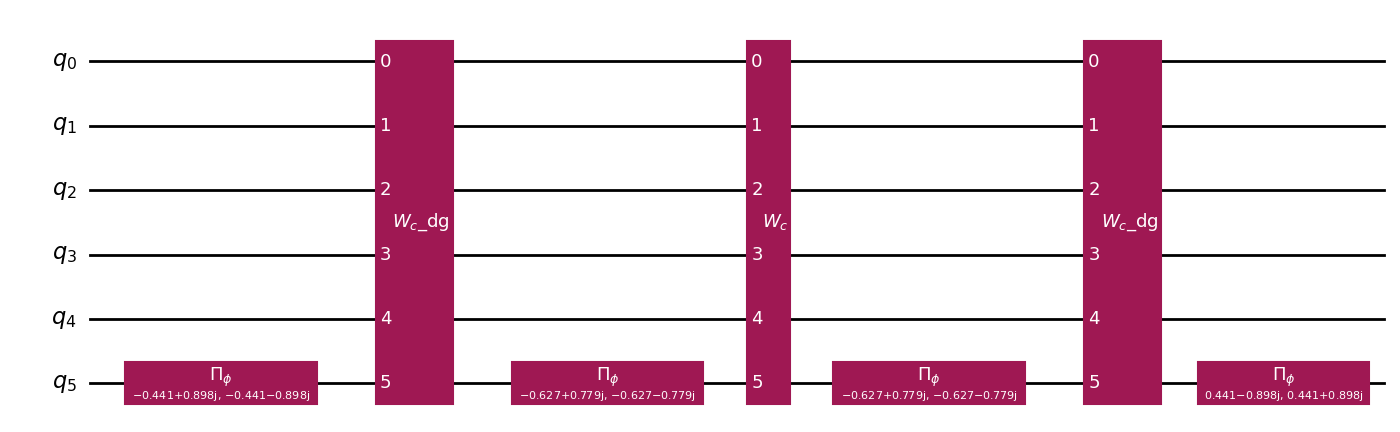

In [152]:
sample_list = get_samples(sparse4, 100, seednumber=0, samplerelative=True)
rcount_qsvt_quick(sparse4,degree=3,delta=15,max_scale=0.98,sample_list=sample_list).draw('mpl')

Note that this procedure gives us an unwanted imaginary part in our QSVT approximation of $\text{sign}(x)$, so we now do $\frac{1}{2\alpha}(P_{QSVT} + P_{QSVT}^*)$ to get the real part, where $\alpha > 1$ from the rescaling of the sign function. Taking the real part is easily implemented by introducing an ancilla, applying a Hadamard gate to put it into the $| +  \rangle$ state. One then applyies $cP(QSVT)$ with control state $0$ and $cP(QSVT)^*$ with control state $1$, followed by another Hadamart gate to reset the ancilla to $| 0 \rangle$.

In [157]:
def rcount_phase_oracle_quick(matrix, sample_list, degree=15, delta=6, max_scale=0.98, row_sparsity=None):
    ''' sends |i> |k> |l> |0> to (-1)^{1_{C(i.k)<l}} |0> 
    Real part controlled by new ancilla bit'''

    if row_sparsity is None:
        row_sparsity = rowsparsity(matrix)

    
    num_qubits = required_qubits(matrix)
    sparse_bits = required_sparse_bits(matrix)

    qsvt_circuit = rcount_qsvt_quick(matrix, sample_list, degree, delta, max_scale, row_sparsity)
    qsvt_circuit.name = r'$P_{QSVT}(W_c)$'
    
    qsvt_adj = qsvt_circuit.inverse()
    qsvt_adj.name = r'$P_{QSVT}(W_c)^{\dagger}$'

    qsvt_control = qsvt_circuit.control(ctrl_state=0)
    qsvt_control.name = r'$cP_{QSVT}(W_c)$'

    qsvtadj_control = qsvt_adj.control(ctrl_state=1)
    qsvtadj_control.name = r'$cP_{QSVT}(W_c)^{\dagger}$'
    
    qr_row = QuantumRegister(num_qubits,name='q_i')
    qr_sparse = QuantumRegister(sparse_bits,name='q_k')
    qr_l = QuantumRegister(num_qubits,name='q_l')
    ar = AncillaRegister(1,name='a') #For encoding
    real_ancilla = AncillaRegister(1,name='r') #To get real part of QSVT function

    phase_oracle_circuit = QuantumCircuit(qr_row,qr_sparse,qr_l,ar,real_ancilla)

    phase_oracle_circuit.h(real_ancilla)

    phase_oracle_circuit.compose(qsvt_control,real_ancilla[:]+qr_row[:]+qr_sparse[:]+qr_l[:]+ar[:], inplace=True)
    phase_oracle_circuit.compose(qsvtadj_control,real_ancilla[:]+qr_row[:]+qr_sparse[:]+qr_l[:]+ar[:], inplace=True)

    phase_oracle_circuit.h(real_ancilla)
    
    return phase_oracle_circuit

[pyqsp.poly.PolySign] degree=15, delta=6
[PolyTaylorSeries] (Cheb) max 0.9725162686162031 is at 0.836462752777381: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.008083841811005776 in the domain [-1, 1] using degree 15


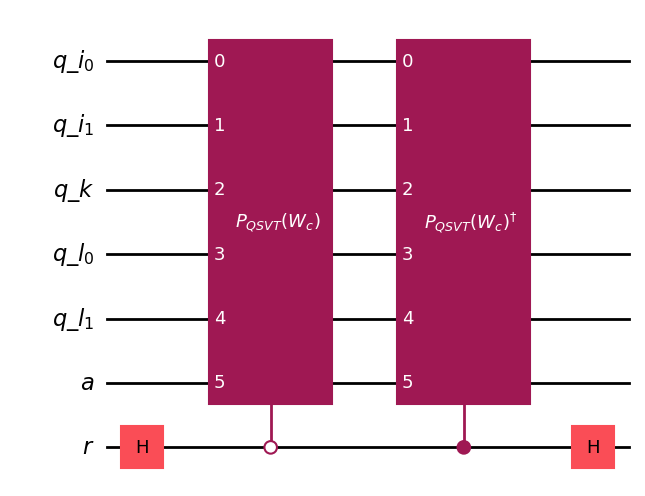

In [158]:
samples = get_samples(sparse4, 100, True)
rcount_phase_oracle_quick(sparse4, samples).draw(output='mpl')

Now we test that our cumulative phase oracle performs as intended. One can check that all non-encoding ancillas are cleaned, so we normalize our statevectors to just be the part corresponding to the encoding block we care about, as all we need is $\langle 0_a|V_c|0_a \rangle$ to be $\sum_{i,j,k} (-1)^{[1_{C(i,l)<k}]}|i \rangle |k \rangle |l \rangle \langle i | \langle k | \langle l |$

In [159]:
matrix = sparse4
samples = get_samples(matrix, 100, True)
test = quick_rcount_phase_check(matrix,samples, degree=11, delta=5, max_scale=0.98)

[pyqsp.poly.PolySign] degree=11, delta=5
[PolyTaylorSeries] (Cheb) max 0.9645358108738107 is at -0.7207631847685815: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.01396926278955855 in the domain [-1, 1] using degree 11
All tests concluded for Cumulative Count Phase Oracle for test matrix 
 [[3 0 0 0]
 [0 0 0 3]
 [0 0 1 0]
 [0 3 0 0]] 

    average error in real part: 4.242929193028561e-27 
 max error: 1.088246467226275e-26 

    average error in angle: 3.130320447764771e-14 
 max error in angle: 5.363571799769478e-14 

    


We see a massive reduction in error at this stage. However, things can still go wrong if our sample count is insufficient, causing $C(i,l)$ to be approximated incorrecltly, causing issues when $C(i,l) = k$ or $C(i,l) = k-1$.

In [160]:
matrix = sparse4
samples = get_samples(matrix, 10, seednumber=0, samplerelative=True)
test = quick_rcount_phase_check(matrix,samples, degree=11, delta=5, max_scale=0.98)

[pyqsp.poly.PolySign] degree=11, delta=5
[PolyTaylorSeries] (Cheb) max 0.9645358108738107 is at -0.7207631847685815: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.01396926278955855 in the domain [-1, 1] using degree 11
All tests concluded for Cumulative Count Phase Oracle for test matrix 
 [[3 0 0 0]
 [0 0 0 3]
 [0 0 1 0]
 [0 3 0 0]] 

    average error in real part: 0.3916127890774087 
 max error: 2.148358106190982 

    average error in angle: 0.3419474225521587 
 max error in angle: 1.8473970564347406 

    


Examples with larger matrices:

In [15]:
matrix = sparse8 # 8 x 8, r_s = 1
samples = get_samples(matrix, 100, seednumber=0, samplerelative=True)
test = quick_rcount_phase_check(matrix,samples, degree=11, delta=5, max_scale=0.98)
pushMessage('checkoracle','check')

[pyqsp.poly.PolySign] degree=11, delta=5
[PolyTaylorSeries] (Cheb) max 0.9645358108738107 is at -0.7207631847685815: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.01396926278955855 in the domain [-1, 1] using degree 11
All tests concluded for Cumulative Count Phase Oracle for test matrix 
 [[3 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0]
 [0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 1]
 [0 0 3 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]] 

    average error in real part: 9.351594919915027e-26 
 max error: 1.9109616444125812e-25 

    average error in angle: 1.2695920315774774e-13 
 max error in angle: 2.2003521345206638e-13 

    


#### Converting Phase Oracle to Cumulative Count Oracle

Now we convert the phase oracle onto an XOR oracle on an ancilla bit:

In [ ]:
def rcumulative_count_oracle_quick(matrix: ArrayLike, sample_list: list[list[float]], degree:int=17, delta:int=6, max_scale:float=0.95, row_sparsity:int=None) -> QuantumCircuit:
    '''Generates circuit O_c for specified matrix, given a list of samples'''

    if row_sparsity == None:
        row_sparsity = rowsparsity(matrix)
        
    num_qubits = required_qubits(matrix)
    sparse_bits = required_sparse_bits(matrix)

    qr_row = QuantumRegister(num_qubits,name='q_i')
    qr_sparse = QuantumRegister(sparse_bits,name='q_k')
    qr_l = QuantumRegister(num_qubits,name='q_l')
    control_ancilla = AncillaRegister(1,name='o') #ancilla for controlled V_c, encodes 1[C(i,l)<k]
    ar = AncillaRegister(2,name='a') #Real part + encoding ancilla

    phase_oracle_circ = rcount_phase_oracle_quick(matrix=matrix, sample_list=sample_list, degree=degree, delta=delta, max_scale=max_scale, row_sparsity=row_sparsity)
    phase_oracle_circ.name = r'$V_c$'

    controlled_VC = phase_oracle_circ.control(1)
    controlled_VC.label = r'$cV_c$'

    cumulative_count_circuit = QuantumCircuit(qr_row,qr_sparse,qr_l,control_ancilla,ar)
    cumulative_count_circuit.x(control_ancilla)
    cumulative_count_circuit.h(control_ancilla)
    cumulative_count_circuit.compose(controlled_VC,control_ancilla[:]+qr_row[:]+qr_sparse[:]+qr_l[:]+ar[:],inplace=True)
    cumulative_count_circuit.h(control_ancilla)
    cumulative_count_circuit.x(control_ancilla)

    return cumulative_count_circuit

[pyqsp.poly.PolySign] degree=17, delta=6
[PolyTaylorSeries] (Cheb) max 0.9465559142081361 is at 1.0: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.004288591624822671 in the domain [-1, 1] using degree 17


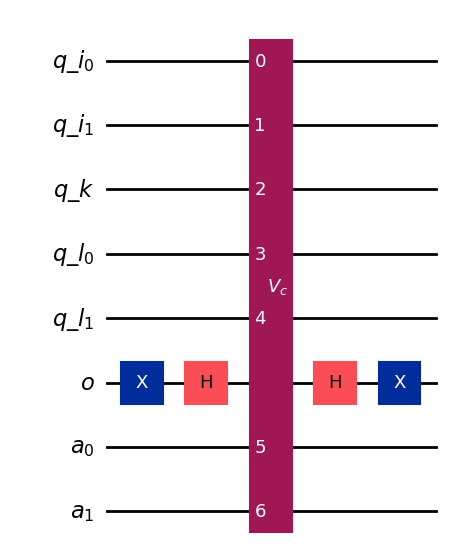

In [22]:
samples = get_samples(sparse4)
rcumulative_count_oracle_quick(sparse4,samples).draw('mpl')

We test the above oracle, by finding the probabilities that our ancilla is in the state $| 1_{C(i,k)<l} \oplus 1 \rangle $.

In [18]:
sample_list = get_samples(sparse4,100,seednumber=0,samplerelative=True)
test = quick_rcumulative_oracle_check(sparse4,sample_list, degree=11, delta=5, max_scale=0.95, row_sparsity=None)

[pyqsp.poly.PolySign] degree=11, delta=5
[PolyTaylorSeries] (Cheb) max 0.9350092044184899 is at -0.7207631847685815: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.013541632296000654 in the domain [-1, 1] using degree 11
All tests concluded for Row Cumulative Count Oracle for test matrix 
 [[3 0 0 0]
 [0 0 0 3]
 [0 0 1 0]
 [0 3 0 0]] 

    average prob that measurement of ancilla bit is in the wrong state: 0.0017830487870790085 
 max prob: 0.0019268856218419561 

    


In the above cell, we saw that with high probability
$$
O_c \colon | 0 \rangle | k \rangle | l \rangle |0 \rangle_1 |0 \rangle_{b} |0 \rangle_b \mapsto |i \rangle | k \rangle | l \rangle | \mathbf{1}\left\{ C(i,l) < k \right\} \rangle_o | 0 \rangle_b |0 \rangle_{b} \quad i,l \in \{0,1\}^n, k \in \{1,\dots,s_r\},
$$
where $b = \lceil \log_2(s_r+1) \rceil$,
for any choice of $|i \rangle |j\rangle |k \rangle$ for our toy example of a $4 \times 4$ matrix with exactly one nonzero entry in each row and column.

#### Row Oracle from Cumulative Counter Oracle

Now that we have the cumulative counter oracle, we show how this can be used to obtain the row sketching oracle
$$
O_A^{\text{ind,row}} \colon | i \rangle | k \rangle \mapsto |i \rangle | j(i,k) \rangle.
$$
The idea is to do a binary search on $l \in \{0,1\}^n$ until we reach the desired column $j(i,k)$, which is the value of $l$  where $C(i,l)$ first changes sign. The procedure uses the oracle $O_c$ to let us obtain each bit of $j(i,k)$ on the ancilla bit, and then swaps it onto the register containing $l$, eventually leaving us with $| i \rangle |k \rangle |j(i,k) \rangle | 0 \rangle$. As the row oracle should send $|i \rangle |k \rangle$ to $| i \rangle | j(i,k) \rangle$, we do another binary search and swaps to move $j(i,k)$ onto the bits storing $| k \rangle$.

The binary search works as following: we begin with the most significant bit of the $l$ register, flipping it to $1$ with an $X$ gate and then running the cumulative count oracle. Whatever the ancilla $o$ changes to is then the first bit of $j(i,k)$: if $C(i,2^{n-1}) < k$ then we get $|0 \rangle_o$ while if $C(i,2^{n-1}) \geq k$ we get $|1 \rangle_o$. Now we flip the $l$ bit with an $X$ gate and swap it with the ancilla bit. This resets the ancilla to $|0 \rangle_o$ and leaves the $l$ register in a state that agrees with $j(i,k)$ on the most significant bit. We then iterate through all bits of the $l$ register, putting it in the state $|j(i,k) \rangle$.

Then we have to clean the k register. and overwrite it with $j(i,k)$. We do a similar binary search. Because of the convention $k \in {1,...,s_r}$ we also have to subtract 1 from the $k$ register first. Note that one could have modified all of the formulas for phase offsets etc. to take $k$ as a binary representation from the outset instead, but we decided to keep the formulas as they are in the paper for clarity and ease of verifying correctness.

In [63]:
def row_index_oracle_quick(matrix: ArrayLike, sample_list: list[list[float]], degree:int=17, delta:int=6, max_scale:float=0.95, row_sparsity:int=None) -> QuantumCircuit:
    ''' sends |i> |k> |0> |0> to |i> |k> |j(i,k)> |0>
    '''
    if row_sparsity is None:
        row_sparsity = rowsparsity(matrix)
    sparsebits = required_sparse_bits(matrix)
    num_qubits = required_qubits(matrix)

    count_oracle_circuit = rcumulative_count_oracle_quick(matrix,sample_list=sample_list, 
    degree=degree, delta=delta, max_scale=max_scale, row_sparsity=row_sparsity)

    q_row = QuantumRegister(num_qubits,name='q_i')
    q_sparse = QuantumRegister(sparsebits,name='q_k')
    q_l = QuantumRegister(num_qubits,name='q_l')
    control_ancilla = AncillaRegister(1,name='o') #Ancilla for controlled V_c, encodes 1[C(i,l)<k]
    extra_ancillas = AncillaRegister(2,name='a') #Ancillas for U_c

    index_oracle_circ = QuantumCircuit(q_row,q_sparse,q_l,control_ancilla,extra_ancillas)

    for m in range(num_qubits):
        bit_index = num_qubits - m - 1 #start with most significant bit for binary search
        index_oracle_circ.x(q_l[bit_index])
        index_oracle_circ.compose(count_oracle_circuit,inplace=True)
        index_oracle_circ.x(q_l[bit_index])
        index_oracle_circ.swap(q_l[bit_index],control_ancilla[0])
        index_oracle_circ.barrier()

    # Clean k register
    # Iterate over bits of k, swap with l
    index_oracle_circ.x(control_ancilla[0])
    index_oracle_circ.compose(subtract_one_circuit(sparsebits),q_sparse[:], inplace=True) # k -> k-1 

    # The following leaves us with |i> |0> |j(i,k)> |0>_o
    for m in range(sparsebits):
        index_oracle_circ.swap(q_sparse[m],control_ancilla[0])
        index_oracle_circ.compose(count_oracle_circuit,inplace=True)
        index_oracle_circ.x(q_sparse[m])
    index_oracle_circ.x(control_ancilla[0]) 

    #swap qubits in l register past k register so that we have |i> |j(i,k)> |0> |0>_o
    for k in range(sparsebits):
        for l in range(num_qubits):
            index_oracle_circ.swap([num_qubits+(sparsebits-k-1)+l],[num_qubits+(sparsebits-k-1)+l+1])

    return index_oracle_circ

[pyqsp.poly.PolySign] degree=17, delta=6
[PolyTaylorSeries] (Cheb) max 0.9465559142081361 is at 1.0: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.004288591624822671 in the domain [-1, 1] using degree 17


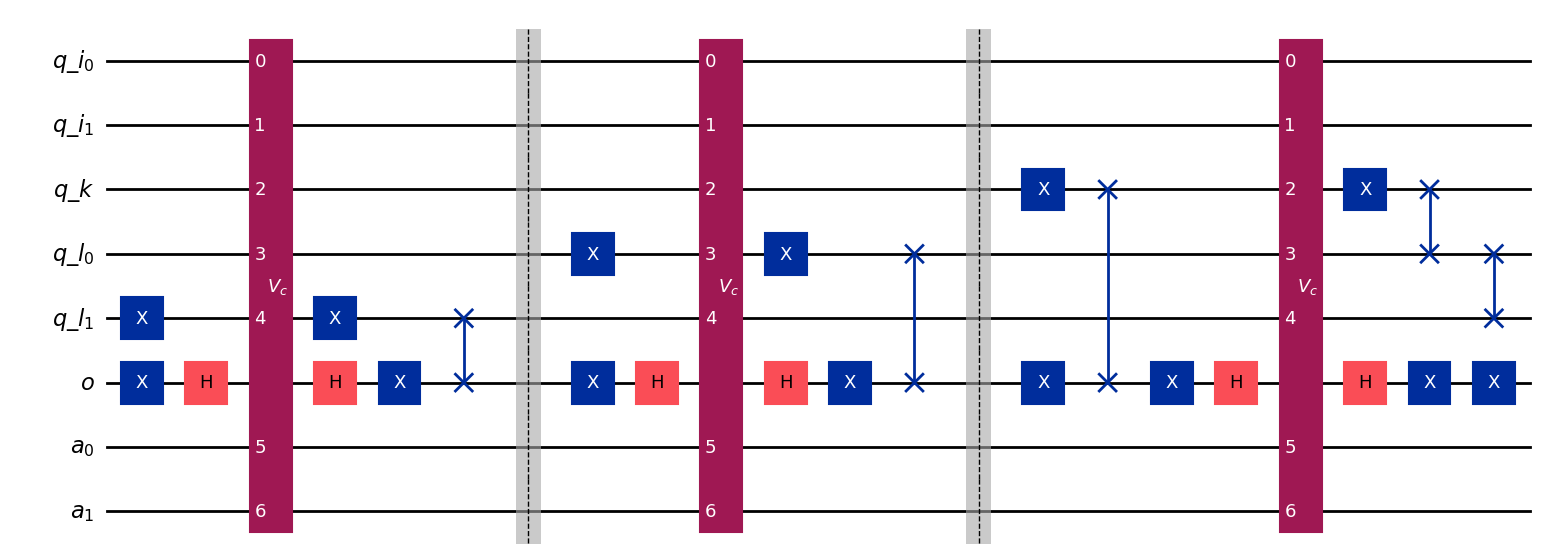

In [ ]:
row_index_oracle_quick(sparse4,get_samples(sparse4)).draw(output='mpl')

The code below records $O_A^{\text{ind,row}} (| i \rangle | 1 \rangle_k |0 \rangle_l |0 \rangle_o)$ for each $i=0, ... ,(2^N - 1)$ and builds a list for the most likely result for the $l$ register along with the probability of that result. Note that our example matrix has $s_r = 1$ so there is only one value of $k$ to test. 

In [15]:
def rowindexquick_test(matrix,sample_list,degree,delta,max_scale,row_sparsity=None,prints=True, buildmatrix=True):
    ''' Tests the accuracy of the cumulative count unitary for a given matrix and sample list
    Makes best guess for j(i,k) and records corresponding probability'''
    guess_list = []
    probs_list = []
    matrix_guess = []
    nonzeros = np.nonzero(matrix)
    if buildmatrix == True:
            matrix_guess = np.zeros_like(matrix)

    if row_sparsity is None:
        row_sparsity = rowsparsity(matrix)
    num_qubits = required_qubits(matrix)
    sparse_bits = required_sparse_bits(matrix)

    q_row = QuantumRegister(num_qubits,name='q_i')
    q_sparse = QuantumRegister(sparse_bits,name='q_k')
    q_l = QuantumRegister(num_qubits,name='q_l')
    control_ancilla = AncillaRegister(1,name='o') #Ancilla for controlled V_c, encodes 1[C(i,l)<k]
    extra_ancillas = AncillaRegister(2,name='a') #Ancillas for U_c

    row_index_oracle_circuit = row_index_oracle_quick(matrix,sample_list,degree,delta,max_scale,row_sparsity)

    initial_l = Statevector.from_int(0,2**num_qubits) # l = 0
    blank_xor = Statevector.from_int(0,2**1) #encoding ancilla
    blank_ar = Statevector.from_int(0,2**2) #encoding ancilla

    blank_state = blank_ar.tensor(blank_xor.tensor(initial_l))
    for i in range(2**num_qubits):
        nonzero_row = np.where(nonzeros[0] == i)
        for k in range(1,row_sparsity+1):
            initial_i = Statevector.from_int(i,2**num_qubits)
            initial_k = Statevector.from_int(k,2**sparse_bits)

            starting_state = blank_state.tensor((initial_k.tensor(initial_i)))
            psi = starting_state.evolve(row_index_oracle_circuit)

            B = 2**(num_qubits*2 + sparse_bits + 1)

            normpsi = psi.data[0:B]/np.linalg.norm(psi.data[0:B])
            psiblock = Statevector(normpsi)

            guess_index = np.where(np.abs(psiblock.probabilities() - np.max(psiblock.probabilities())) < 0.01)

            helper_index = nonzero_row[0][k-1]
            correct_index = nonzeros[1][helper_index] #picks out j(i,k)
            # display(f'helper index is {helper_index} and correct index is {correct_index}')

            successprob = psiblock.probabilities()[i + 2**num_qubits*correct_index] #prob of guess being correct
            guess_j = guess_index[0][0] // (2**(num_qubits))
            # display(f'success prob index is {2**num_qubits*correct_index}')
            # display(f'success probability is {successprob} and guess is {guess_j}')

            guess_list.append(int(guess_j))
            probs_list.append(successprob)
            if buildmatrix == True:
                matrix_guess[i][guess_j] = 1

    correct_matrix = np.where(matrix > 1e-10, 1, 0)

    if prints == True:
        print(f'''Using row index oracle, guessing support of \n {matrix} \n to be... \n {matrix_guess}''')

        if np.allclose(matrix_guess,correct_matrix) == True:
            print('Correctly guessed matrix!')
    
    return guess_list, probs_list, matrix_guess

In [16]:
matrix = sparse4
sample_list = get_samples(matrix,30,seednumber=0,samplerelative=True)
rtest = rowindexquick_test(matrix,sample_list, degree=7, delta=5, max_scale=0.95, row_sparsity=None)
print(f'Average prob of correct entry = {np.mean(rtest[1])}')
print(f'Lowest prob of correct entry = {np.min(rtest[1])}')

[pyqsp.poly.PolySign] degree=7, delta=5
[PolyTaylorSeries] (Cheb) max 0.8803531262833838 is at 0.4334930350638173: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.044847963093493676 in the domain [-1, 1] using degree 7
Using row index oracle, guessing support of 
 [[3 0 0 0]
 [0 0 0 3]
 [0 0 1 0]
 [0 3 0 0]] 
 to be... 
 [[1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]]
Correctly guessed matrix!
Average prob of correct entry = 0.9737001416568799
Lowest prob of correct entry = 0.9610777311134183


We can define the column oracle quickly by taking the row oracle of the transpose matrix. In practice, we would just interchange the roles of $i$ and $j$ when applying the gates determined by our sample.

In [155]:
def col_index_oracle_quick(matrix: ArrayLike, sample_list: list[list[float]], degree:int=17, delta:int=6, max_scale:float=0.95, col_sparsity:int=None) -> QuantumCircuit:
    transpose_sample_list = sample_list.copy()
    for i in range(len(transpose_sample_list)):
        transpose_sample_list[i][0], transpose_sample_list[i][1] = transpose_sample_list[i][1], transpose_sample_list[i][0] 
    return row_index_oracle_quick(matrix.T, sample_list, degree, delta, max_scale, row_sparsity=col_sparsity)

In [17]:
matrix = sparse4_2
sample_list = get_samples(matrix,30,seednumber=0,samplerelative=True)
ctest = colindexquick_test(matrix,sample_list, degree=7, delta=5, max_scale=0.95, col_sparsity=None)
print(f'Average prob of correct entry = {np.mean(ctest[1])}')
print(f'Lowest prob of correct entry = {np.min(ctest[1])}')

[pyqsp.poly.PolySign] degree=7, delta=5
[PolyTaylorSeries] (Cheb) max 0.8803531262833838 is at 0.4334930350638173: normalizing
[PolyTaylorSeries] (Cheb) average error = 0.044847963093493676 in the domain [-1, 1] using degree 7
Using column index oracle, guessing support of 
 [[0 0 1 0]
 [0 1 0 0]
 [0 0 0 1]
 [3 0 0 0]] 
 to be... 
 [[0 0 1 0]
 [0 1 0 0]
 [0 0 0 1]
 [1 0 0 0]]
Correctly guessed matrix!
Average prob of correct entry = 0.9758674689902898
Lowest prob of correct entry = 0.9610777311134325


Example for $4 \times 4$ matrix with $r_s = 2$:

If we increase our sample size, our odds of a correct guess increases noticeably:

#### Testing accuracy of row and column index oracles

We shall work with $4\times 4$ matrices due to memory constraints. We shall plot how sample size over number of nonzero entries affects the accuracy of the row index oracle (the column index oracle will be analogous), which we plot on a line graph. We shall include cases of different sparsity levels. 

In [ ]:
matrix_dict = {"sparse4": sparse4,"mid4": mid4, "dense4": dense4}
s4samples = get_samples(sparse4,50,seednumber=100,samplerelative=True)
m4samples = get_samples(mid4,50,seednumber=100,samplerelative=True)
d4samples = get_samples(dense4,50,seednumber=100,samplerelative=True)

samples_list_dict = {"sparse4": s4samples,"mid4": m4samples, "dense4": d4samples}

relsample_sizes = np.arange(5,30,5)

for key in matrix_dict.keys():
    listofprob_lists = []
    matrix = matrix_dict[key]
    sup = np.count_nonzero(matrix)
    for M in relsample_sizes:
        res = rowindexquick_test(matrix,samples_list_dict[key][:M*sup], degree=15, delta=7, max_scale=0.98, row_sparsity=None, prints=False, buildmatrix=False)
        listofprob_lists.append(res[1])
    file = np.load(f'./data/{key}error.npz')
    file = dict(file)
    file['probs5to25_d15_delta7'] = listofprob_lists
    np.savez(f'./data/{key}error.npz',**file)

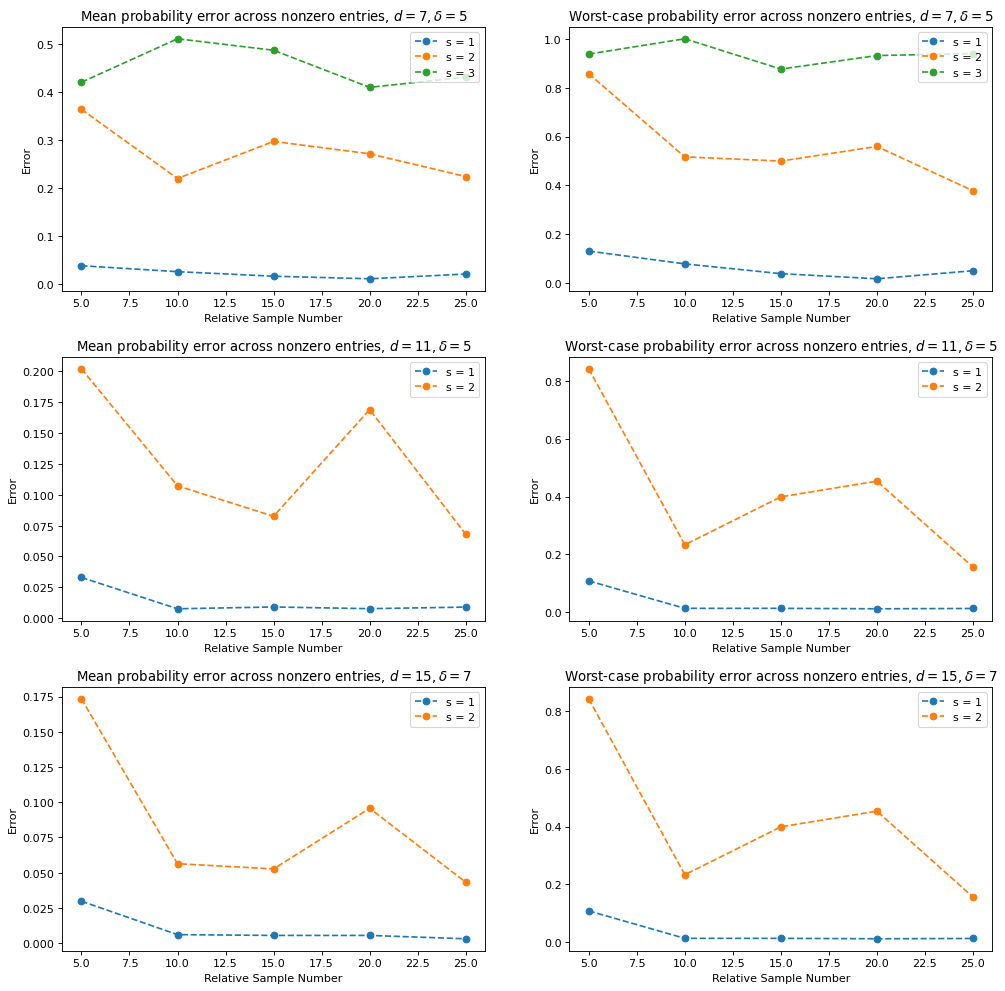

In [42]:
sparse4file = np.load('data/sparse4error.npz')
mid4file = np.load('data/mid4error.npz')
dense4file = np.load('data/dense4error.npz')
sparse8file = np.load('data/sparse8error.npz')

s4probsd7 = sparse4file['probs5to25_d7_delta5']
m4probsd7 = mid4file['probs5to25_d7_delta5']
d4probsd7 = dense4file['probs5to25_d7_delta5']
samplesd7 = np.arange(5,30,5)
s4_d7_mean = np.mean(1-s4probsd7,axis=1)
s4_d7_wor = np.max(1-s4probsd7,axis=1)
m4_d7_mean = np.mean(1-m4probsd7,axis=1)
m4_d7_wor = np.max(1-m4probsd7,axis=1)
d4_d7_mean = np.mean(1-d4probsd7,axis=1)
d4_d7_wor = np.max(1-d4probsd7,axis=1)
s4probsd11 = sparse4file['probs5to25_d11_delta5']
m4probsd11 = mid4file['probs5to25_d11_delta5']
samplesd11 = np.arange(5,30,5)
s4_d11_mean = np.mean(1-s4probsd11,axis=1)
s4_d11_worst = np.max(1-s4probsd11,axis=1)
m4_d11_mean = np.mean(1-m4probsd11,axis=1)
m4_d11_worst = np.max(1-m4probsd11,axis=1)

s4probsd15 = sparse4file['probs5to25_d15_delta7']
m4probsd15 = mid4file['probs5to25_d15_delta7']
samplesd15 = np.arange(5,30,5)
s4_d15_mean = np.mean(1-s4probsd15,axis=1)
s4_d15_worst = np.max(1-s4probsd15,axis=1)
m4_d15_mean = np.mean(1-m4probsd15,axis=1)
m4_d15_worst = np.max(1-m4probsd15,axis=1)


plt.figure(figsize=(15, 15), dpi=80)
plt.subplot(321)

plt.plot(samplesd7,s4_d7_mean,label=f's = 1',marker='o',linestyle='--')
plt.plot(samplesd7,m4_d7_mean,label=f's = 2',marker='o',linestyle='--')
plt.plot(samplesd7,d4_d7_mean,label=f's = 3',marker='o',linestyle='--')

plt.title(r'Mean probability error across nonzero entries, $d=7, \delta=5$')
plt.xlabel('Relative Sample Number')
plt.ylabel('Error')
plt.legend(loc='upper right')

plt.subplot(322)

plt.plot(samplesd7,s4_d7_wor,label=f's = 1',marker='o',linestyle='--')
plt.plot(samplesd7,m4_d7_wor,label=f's = 2',marker='o',linestyle='--')
plt.plot(samplesd7,d4_d7_wor,label=f's = 3',marker='o',linestyle='--')
plt.title(r"Worst-case probability error across nonzero entries, $d=7, \delta=5$")
plt.xlabel('Relative Sample Number')
plt.ylabel('Error')

plt.subplots_adjust(hspace=0.25)
plt.legend(loc='upper right')

plt.subplot(323)

plt.plot(samplesd11,s4_d11_mean,label=f's = 1',marker='o',linestyle='--')
plt.plot(samplesd11,m4_d11_mean,label=f's = 2',marker='o',linestyle='--')

plt.title(r'Mean probability error across nonzero entries, $d=11, \delta=5$')
plt.xlabel('Relative Sample Number')
plt.ylabel('Error')
plt.legend(loc='upper right')

plt.subplot(324)

plt.plot(samplesd11,s4_d11_worst,label=f's = 1',marker='o',linestyle='--')
plt.plot(samplesd11,m4_d11_worst,label=f's = 2',marker='o',linestyle='--')
plt.title(r"Worst-case probability error across nonzero entries, $d=11, \delta=5$")
plt.xlabel('Relative Sample Number')
plt.ylabel('Error')

plt.legend(loc='upper right')

plt.subplot(325)

plt.plot(samplesd15,s4_d15_mean,label=f's = 1',marker='o',linestyle='--')
plt.plot(samplesd15,m4_d15_mean,label=f's = 2',marker='o',linestyle='--')

plt.title(r'Mean probability error across nonzero entries, $d=15, \delta=7$')
plt.xlabel('Relative Sample Number')
plt.ylabel('Error')
plt.legend(loc='upper right')

plt.subplot(326)

plt.plot(samplesd15,s4_d11_worst,label=f's = 1',marker='o',linestyle='--')
plt.plot(samplesd15,m4_d11_worst,label=f's = 2',marker='o',linestyle='--')
plt.title(r"Worst-case probability error across nonzero entries, $d=15, \delta=7$")
plt.xlabel('Relative Sample Number')
plt.ylabel('Error')

plt.legend(loc='upper right')

plt.show()

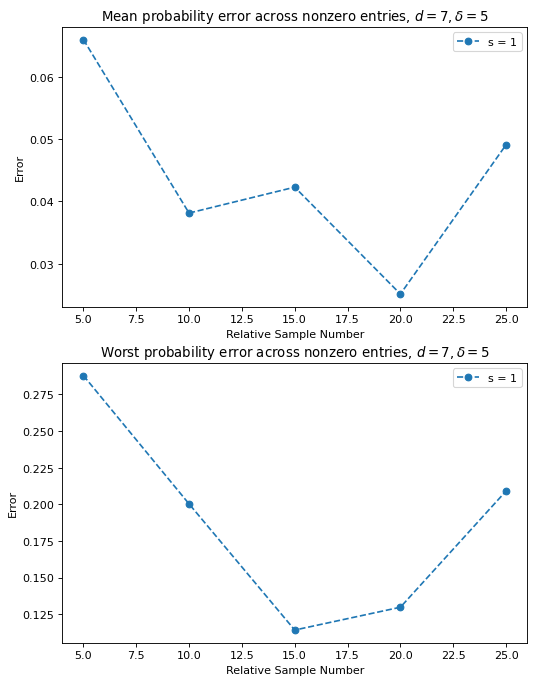

In [44]:
s8probsd7 = sparse8file['probs5to25_d7_delta5']
samplesd7 = np.arange(5,30,5)
s8_d7_mean = np.mean(1-s8probsd7,axis=1)
s8_d7_wor = np.max(1-s8probsd7,axis=1)

plt.figure(figsize=(7.5, 10), dpi=80)
plt.subplot(211)
plt.plot(samplesd7,s8_d7_mean,label=f's = 1',marker='o',linestyle='--')

plt.title(r'Mean probability error across nonzero entries, $d=7, \delta=5$')
plt.xlabel('Relative Sample Number')
plt.ylabel('Error')
plt.legend(loc='upper right')

plt.subplot(212)
plt.plot(samplesd7,s8_d7_wor,label=f's = 1',marker='o',linestyle='--')

plt.title(r'Worst probability error across nonzero entries, $d=7, \delta=5$')
plt.xlabel('Relative Sample Number')
plt.ylabel('Error')
plt.legend(loc='upper right')
plt.show()

When $P_{\text{QSVT}}$ has degree $7$ and $\delta = 5$, we see that the errors for $s_r = 2$ and $s_r = 3$ are still very high. This could be due to the threshold value $\frac{\pi}{4s_r+1}$ being too small, requiring a better approximation of $\text{sign}(x)$ near 0 for QSVT. When we increase the degree of $P_{\text{QSVT}}$ to $11$ we see that the mean and maximum error has decreased for $r_s = 2$. We then try increasing degree to $15$ and $\delta$ to $7$, which causes the neighborhood of zero where $\text{erf}(\delta x)$ jumps from close to $-1$ to close to $+1$ to shrink, and therefore the same goes for the polynomial approximation.

We then plot the probability of incorrectly indentifying $j(i,k)$ using the row index oracle for an $8 \times 8$ matrix with $s_r = 1$ and $P_{\text{QSVT}}$ with degree $7$ and $\delta = 5$. We observe that the mean and maximum error is higher than for the $4 \times 4$ matrix with $s_r = 1$, but noticeably lower than for $4 \times 4$ with $s_r = 2$ for the same degree and $\delta$.

#### A selection of example matrices for testing ####

In [3]:
example_sparse_matrix = generate_random_sparse(4,2,0.5,seed=10)
print(f'example sparse matrix:\n {example_sparse_matrix}')

example sparse matrix:
 [[3 1 0 0]
 [2 0 0 3]
 [0 2 3 0]
 [0 0 3 0]]


In [4]:
sparse4 = generate_random_sparse(matrix_dimension=4, bitlength=2, sparsity=0.25, seed=15) # r_s=1, 1 bit for k
print(f'sparse4: \n {sparse4}')

sparse4: 
 [[3 0 0 0]
 [0 0 0 3]
 [0 0 1 0]
 [0 3 0 0]]


In [5]:
sparse4_2 = generate_random_sparse(matrix_dimension=4, bitlength=2, sparsity=0.25, seed=16)# r_s=1 , 1 bit for k
print(f'sparse4_2: \n {sparse4_2}')

sparse4_2: 
 [[0 0 1 0]
 [0 1 0 0]
 [0 0 0 1]
 [3 0 0 0]]


In [6]:
mid4 = generate_random_sparse(matrix_dimension=4, bitlength=2, sparsity=0.5, seed=18) # r_s = 2, 2 bits for k
print(f'mid4: \n {mid4}')

mid4: 
 [[0 2 0 2]
 [2 0 2 0]
 [0 1 0 1]
 [2 0 2 0]]


In [7]:
dense4 = generate_random_sparse(matrix_dimension=4, bitlength=2, sparsity=0.75, seed=9) #r_s = 3
print(f'dense4: \n {dense4}')

dense4: 
 [[2 2 3 0]
 [3 2 0 1]
 [0 1 2 2]
 [3 0 3 1]]


In [8]:
full4 = generate_random_sparse(4,2,1)
print(f'full4 = \n {full4}')

full4 = 
 [[3 1 2 3]
 [2 3 1 3]
 [3 1 3 3]
 [2 2 2 1]]


In [9]:
sparse8 = generate_random_sparse(8,2,0.125, seed=704) # r_s=1, 1 bit for k
print(f'sparse8: \n {sparse8}')

sparse8: 
 [[3 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0]
 [0 0 0 0 2 0 0 0]
 [0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 1]
 [0 0 3 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]]


In [10]:
mid8 = generate_random_sparse(matrix_dimension=8, bitlength=2, sparsity=3/8, seed=432) # r_s = 3, need 2 bits for k
print(f'mid8: \n {mid8}')

mid8: 
 [[3 0 0 0 3 3 0 0]
 [3 0 0 0 0 3 0 1]
 [3 0 1 0 0 0 3 0]
 [0 0 1 2 0 0 2 0]
 [0 3 0 0 0 0 1 2]
 [0 1 3 2 0 0 0 0]
 [0 0 0 0 1 1 0 3]
 [0 3 0 2 3 0 0 0]]


In [11]:
dense8 = generate_random_sparse(8,2,0.75,seed=143) # r_s = 6, need 3 bits for k 
print(f'dense8: \n {dense8}')

dense8: 
 [[1 1 2 0 0 2 3 2]
 [2 1 2 3 0 3 0 2]
 [1 0 2 3 2 0 3 1]
 [2 3 2 2 3 3 0 0]
 [0 3 2 0 2 2 3 2]
 [0 2 0 2 2 1 3 2]
 [1 0 0 2 3 2 3 2]
 [2 2 2 3 2 0 2 0]]
